# Graph ML Premier Dataset


- Quentin GUIGNARD
- Corentin LASNE
- Zacharie BOUMARD

Lien Github : https://github.com/QuentinG0304/Graph_ML

## Description du dataset : PubMed

### Contexte général

Le dataset **PubMed** est un jeu de données de référence largement utilisé en **graph learning**, en particulier pour l’évaluation de méthodes de **node classification** en apprentissage semi-supervisé.

Il a été introduit et popularisé dans le cadre des travaux sur les graphes de citations scientifiques, notamment dans l’article :

> **Yang, Z., Cohen, W. W., & Salakhutdinov, R. (2016)**  
> *Revisiting Semi-Supervised Learning with Graph Embeddings* (ICML)

Ce dataset fait partie de la famille des datasets **Planetoid**, aux côtés de **Cora** et **CiteSeer**, et est aujourd’hui accessible directement via la bibliothèque **PyTorch Geometric**. LIttérature Planétoide : https://pytorch-geometric.readthedocs.io/en/2.5.1/generated/torch_geometric.datasets.Planetoid.html

---

### Sémantique du graphe

Le graphe PubMed est un **graphe de citations scientifiques** :

- **Nœuds** : articles scientifiques issus de la base PubMed.
- **Arêtes** : relations de citation entre articles.
  - Si un article cite un autre, une arête est ajoutée entre les deux nœuds.
  - Le graphe est traité comme **non orienté**.
- **Attributs** : vecteurs TF-IDF représentant le contenu textuel des articles. Ces valeurs traduisent l'importance  dans le résumé de l'article de 500 mots-clés extraits du dictionnaire médical.
- **Labels** : catégories thématiques (3 classes), correspondant à des domaines de recherche biomédicaux.

L’hypothèse fondamentale exploitée par les méthodes de graph learning est la suivante :

> *Des articles proches dans le graphe de citations ont tendance à appartenir à la même thématique scientifique.*

---


### Caractéristiques globales du dataset

Les statistiques usuelles du dataset PubMed sont :

- **Nombre de nœuds** : 19 717  
- **Nombre d’arêtes** : 44 338  
- **Nombre de classes** : 3  
- **Dimension des features** : 500  

## Installation des modules nécessaires

In [1]:
!pip install torch
!pip install torch-geometric
!pip install pandas
!pip install networkx
!pip install python-louvain


## Importation des modules

## Vue d’ensemble du notebook


Ce notebook couvre les grandes étapes suivantes, alignées sur les modules du cours :


1. **Exploration du graphe** : statistiques, distribution des degrés, homophilie
2. **Centralités** : Degree, PageRank, Betweenness (cours *GraphProperties*)
3. **Diffusion / Influence** : modèle Independent Cascade (cours *lInfluenceMaximisation*)
4. **Détection de communautés** : Louvain + k-core (cours *communityDetection*)
5. **Shallow Embeddings** : Node2Vec baseline (cours *graphShallowEmbeddings*)
6. **GNN – Node Classification** : GCN et GraphSAGE avec analyse de l’over-smoothing
7. **GNN – Link Prediction** : GCN / GraphSAGE / GAT avec `RandomLinkSplit`, BCE loss, AUC/AP

In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv, SAGEConv
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import roc_auc_score, average_precision_score



c:\Users\quent\Desktop\CentraleSupélec\Graph Machine Learning\Graph_ML\.venv\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\quent\Desktop\CentraleSupélec\Graph Machine Learning\Graph_ML\.venv\Lib\site-packages\torch_cluster\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\quent\Desktop\CentraleSupélec\Graph Machine Learning\Graph_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Chargement du dataset

In [13]:
dataset = Planetoid(root="data/Planetoid", name="PubMed", split="random", num_train_per_class=3000, num_val=5000, num_test=6000,transform=NormalizeFeatures())

# Le dataset Planetoid contient un seul graphe
data = dataset[0]
# objet Data contenant :
  # x : features des nœuds
  # edge_index : arêtes
  # y : labels
  # train_mask, val_mask, test_mask

# Liste des mots clefs from https://huggingface.co/datasets/gcaillaut/pubmed/blob/main/pubmed.py?
_WORD_FEATURES = ["w-rat", "w-common", "w-use", "w-examin", "w-pathogenesi", "w-retinopathi", "w-mous", "w-studi", "w-anim", "w-model", "w-metabol", "w-abnorm", "w-contribut", "w-develop", "w-investig", "w-mice", "w-2", "w-month", "w-compar", "w-obtain", "w-method", "w-induc", "w-6", "w-inject", "w-experiment", "w-normal", "w-diet", "w-30", "w-hyperglycemia", "w-level", "w-lipid", "w-oxid", "w-activ", "w-protein", "w-kinas", "w-c", "w-measur", "w-result", "w-increas", "w-retin", "w-stress", "w-3", "w-similar", "w-observ", "w-conclus", "w-play", "w-import", "w-role", "w-present", "w-p", "w-m", "w-r", "w-muscl", "w-control", "w-chang", "w-dure", "w-lower", "w-higher", "w-mass", "w-correl", "w-decreas", "w-determin", "w-concentr", "w-stimul", "w-period", "w-caus", "w-mark", "w-group", "w-evid", "w-fast", "w-type", "w-signific", "w-differ", "w-ratio", "w-suggest", "w-degre", "w-occur", "w-vivo", "w-respect", "w-dysfunct", "w-region", "w-high", "w-appear", "w-sever", "w-affect", "w-cardiovascular", "w-complic", "w-primari", "w-death", "w-patient", "w-clinic", "w-suscept", "w-cardiac", "w-tissu", "w-specif", "w-function", "w-defect", "w-possibl", "w-indic", "w-state", "w-onli", "w-bodi", "w-weight", "w-loss", "w-valu", "w-howev", "w-4", "w-condit", "w-durat", "w-8", "w-week", "w-onset", "w-data", "w-direct", "w-report", "w-provid", "w-addit", "w-evalu", "w-sensit", "w-heart", "w-object", "w-mean", "w-blood", "w-glucos", "w-strong", "w-hba", "w-1c", "w-a1c", "w-variabl", "w-independ", "w-assess", "w-relat", "w-trial", "w-research", "w-design", "w-profil", "w-sampl", "w-particip", "w-n", "w-1", "w-consist", "w-befor", "w-min", "w-predict", "w-adjust", "w-sex", "w-treatment", "w-7", "w-gt", "w-0", "w-larg", "w-influenc", "w-base", "w-standard", "w-14", "w-10", "w-wherea", "w-enhanc", "w-manag", "w-day", "w-secret", "w-cholesterol", "w-insulin", "w-24", "w-h", "w-low", "w-rate", "w-fatti", "w-acid", "w-effect", "w-hormon", "w-hepat", "w-contrast", "w-product", "w-major", "w-plasma", "w-current", "w-flow", "w-chronic", "w-mechan", "w-test", "w-therefor", "w-analys", "w-mrna", "w-streptozotocin", "w-did", "w-15", "w-g", "w-25", "w-mmol", "w-l", "w-5", "w-reduc", "w-number", "w-densiti", "w-posit", "w-cell", "w-17", "w-mm", "w-18", "w-induct", "w-associ", "w-express", "w-glycem", "w-respons", "w-therapi", "w-random", "w-initi", "w-ani", "w-singl", "w-new", "w-agent", "w-metformin", "w-medic", "w-glycosyl", "w-hemoglobin", "w-analysi", "w-baselin", "w-health", "w-factor", "w-process", "w-care", "w-9", "w-01", "w-95", "w-interv", "w-ci", "w-12", "w-reduct", "w-achiev", "w-target", "w-lt", "w-diseas", "w-class", "w-age", "w-obes", "w-renal", "w-improv", "w-progress", "w-noninsulindepend", "w-mellitus", "w-becaus", "w-s", "w-index", "w-hypertens", "w-need", "w-followup", "w-year", "w-mg", "w-dl", "w-remain", "w-subject", "w-treat", "w-oral", "w-requir", "w-0001", "w-mortal", "w-includ", "w-vs", "w-background", "w-poor", "w-drug", "w-13", "w-rang", "w-combin", "w-intervent", "w-daili", "w-dose", "w-100", "w-toler", "w-receiv", "w-11", "w-postprandi", "w-kg", "w-hypoglycemia", "w-frequent", "w-event", "w-versus", "w-symptom", "w-incid", "w-parent", "w-complex", "w-longterm", "w-inhibitor", "w-peripher", "w-nerv", "w-stz", "w-conduct", "w-demonstr", "w-frequenc", "w-inhibit", "w-neuropathi", "w-pathway", "w-shown", "w-time", "w-ii", "w-individu", "w-adult", "w-50", "w-60", "w-diagnosi", "w-healthi", "w-follow", "w-young", "w-seen", "w-alter", "w-gene", "w-e", "w-identifi", "w-previous", "w-mediat", "w-vascular", "w-lipoprotein", "w-involv", "w-phenotyp", "w-confirm", "w-variant", "w-endotheli", "w-potenti", "w-disord", "w-popul", "w-nonobes", "w-aim", "w-serum", "w-hba1c", "w-hypoglycaemia", "w-continu", "w-case", "w-impair", "w-risk", "w-known", "w-men", "w-women", "w-40", "w-complet", "w-estim", "w-like", "w-particular", "w-human", "w-character", "w-elev", "w-synthesi", "w-greater", "w-small", "w-reveal", "w-liver", "w-niddm", "w-genet", "w-receptor", "w-growth", "w-pancreat", "w-betacel", "w-molecul", "w-enzym", "w-regul", "w-polymorph", "w-total", "w-allel", "w-02", "w-resist", "w-cpeptid", "w-hypothesi", "w-perform", "w-score", "w-001", "w-05", "w-histori", "w-action", "w-approxim", "w-suppress", "w-glucagon", "w-ml", "w-x", "w-free", "w-peopl", "w-uptak", "w-intens", "w-relationship", "w-prevent", "w-autoimmun", "w-recent", "w-preval", "w-nondiabet", "w-genotyp", "w-conclud", "w-linkag", "w-islet", "w-peptid", "w-form", "w-membran", "w-transgen", "w-failur", "w-isol", "w-negat", "w-earli", "w-famili", "w-chromosom", "w-immun", "w-support", "w-16", "w-cohort", "w-insulindepend", "w-outcom", "w-screen", "w-approach", "w-infus", "w-multipl", "w-depend", "w-physic", "w-transport", "w-acut", "w-releas", "w-presenc", "w-glycaem", "w-male", "w-antibodi", "w-femal", "w-pattern", "w-t2dm", "w-promot", "w-fat", "w-d", "w-bmi", "w-haplotyp", "w-triglycerid", "w-interact", "w-marker", "w-describ", "w-area", "w-20", "w-cytokin", "w-bind", "w-bb", "w-alpha", "w-beta", "w-cd4", "w-spontan", "w-given", "w-vitro", "w-basal", "w-protect", "w-pressur", "w-detect", "w-exercis", "w-children", "w-adolesc", "w-life", "w-b", "w-antigen", "w-iddm", "w-american", "w-hla", "w-arteri", "w-nephropathi", "w-review", "w-destruct", "w-content", "w-autoantibodi", "w-dm", "w-select", "w-infect", "w-recipi", "w-intak", "w-placebo", "w-db", "w-pancrea", "w-diagnos", "w-glomerular", "w-albumin", "w-excret", "w-syndrom", "w-t", "w-lymphocyt", "w-produc", "w-coronari", "w-status", "w-microalbuminuria", "w-nod", "w-mhc", "w-insul", "w-administr", "w-revers", "w-transplant", "w-graft", "w-t1d", "w-lead", "w-v", "w-dietari", "w-general", "w-macrophag", "w-kidney", "w-urinari", "w-myocardi", "w-meal", "w-ica", "w-locus", "w-tcell", "w-depress", "w-bone", "w-mutat"]

# Conversion en graphe network x
G = to_networkx(
    data,
    node_attrs=["x", "y"],   # features et labels
    to_undirected=True
)

## Statistiques Descriptives du Graph

In [14]:
nb_noeud = G.number_of_nodes()
nb_arete = G.number_of_edges()
print(f"Nombre de noeuds : {nb_noeud}")
print(f"Nombre d'arêtes : {nb_arete}")

# Densité
density = nx.density(G)
print(f"Densité du graphe: {density:.5f}")

# Composantes connexes
if nx.is_connected(G):
  print("Le graphe est connexe.")
else:
  print(f"Le graphe n'est pas connexe.")

# Graphe non dririgé
if nx.is_directed(G):
  print(f"Le graphe n'est pas dirigé.")
else:
  print(f"Le graphe est dirigé.")

# Attributs et labales
print(f'Nombre de features par nœud: {dataset.num_features} (Mots-clés)')
print(f'Nombre de classes à prédire  : {dataset.num_classes} (Types de diabète)')

# Effectifs par classes
def get_instances_per_class(data):
  y = data.y.cpu().numpy()
  labels, counts = np.unique(y, return_counts=True)
  df_counts = pd.DataFrame({
      "label_id": labels,
      "count": counts
  })
  return (df_counts)

df_counts = get_instances_per_class(data)
print("Effectifs par classes")
print(df_counts)
print("Les nombres d'instances par classe sont plutôt équilibrés.")

X = data.x.cpu().numpy()

print('==================')
print('Statistiques attributs - data normalisées')
df_vocab = pd.DataFrame({
    "feature_id": np.arange(len(_WORD_FEATURES)),
    "token": _WORD_FEATURES,
    "min": X.min(axis=0),
    "max": X.max(axis=0),
    "mean": X.mean(axis=0),
    "std": X.std(axis=0),
    "non_zero_ratio": (X > 0).mean(axis=0)
})
print(df_vocab.head())



Nombre de noeuds : 19717
Nombre d'arêtes : 44324
Densité du graphe: 0.00023
Le graphe est connexe.
Le graphe est dirigé.
Nombre de features par nœud: 500 (Mots-clés)
Nombre de classes à prédire  : 3 (Types de diabète)
Effectifs par classes
   label_id  count
0         0   4103
1         1   7739
2         2   7875
Les nombres d'instances par classe sont plutôt équilibrés.
Statistiques attributs - data normalisées
   feature_id          token  min       max      mean       std  \
0           0          w-rat  0.0  0.232743  0.008819  0.022614   
1           1       w-common  0.0  0.137954  0.001586  0.006408   
2           2          w-use  0.0  0.099184  0.003431  0.006384   
3           3       w-examin  0.0  0.087849  0.002287  0.005756   
4           4  w-pathogenesi  0.0  0.100051  0.001355  0.005986   

   non_zero_ratio  
0        0.195567  
1        0.080590  
2        0.356241  
3        0.182939  
4        0.063701  


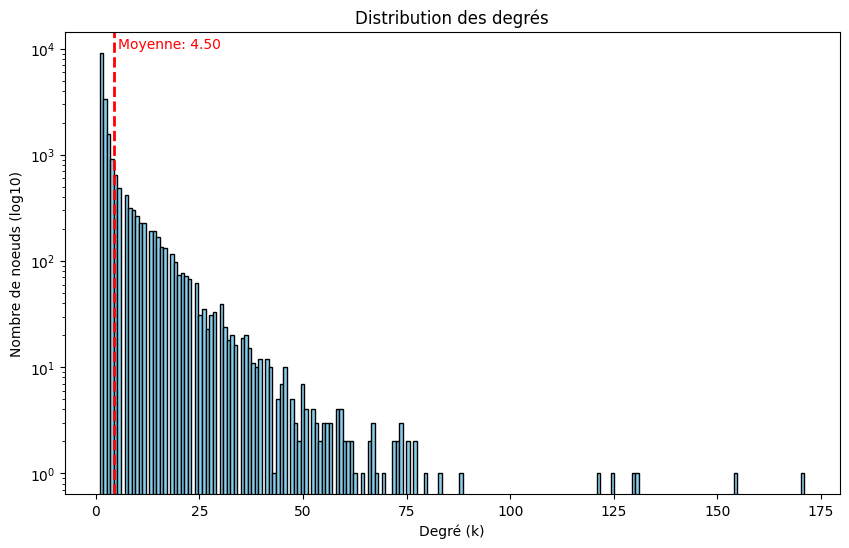

In [15]:
# Degrés
degrees = [d for n, d in G.degree()]
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=200, color='skyblue', edgecolor='black')
plt.axvline(np.mean(degrees), color='red', linestyle='dashed', linewidth=2)
# Afficher la valeur de la moyenne sur le graphe à côté de la ligne rouge en la mettant plutôt en haut de l'image
plt.text(np.mean(degrees) + 1, 10000, f'Moyenne: {np.mean(degrees):.2f}', color='red')

plt.title("Distribution des degrés")
plt.xlabel("Degré (k)")
plt.ylabel("Nombre de noeuds (log10)")
plt.yscale('log')

plt.show()

Analyse de l'histogramme:

- La distribution suit une loi de décroissance exponentielle attendue. La moyenne est de 4.50. Cela indique qu'en moyenne chaque publication a été citée un peu moins de 5 fois au sein du réseau.
- On peut observer des outliers qui représentent des hubs qui ont des degrés très importants. Ils peuvent représenter des papiers fortement cités et donc références fondamentales dans leur domaine d'étude.


In [16]:
# ===== Test de l'hypothèse de l'homophilie sur les labels ========

# Test d'une homophilie générale
def edge_homophily(G, labels):
    same = 0
    for u, v in G.edges():
        if labels[u] == labels[v]:
            same += 1
    return same / G.number_of_edges()

labels = nx.get_node_attributes(G, "y")
h_obs = edge_homophily(G, labels)
print(f"Homophilie observée : {h_obs:.3f}")

# Comparaison avec le hasard
def random_homophily(G, labels, n_perm=100):
    nodes = list(labels.keys())
    y = np.array([labels[n] for n in nodes])
    h_rand = []

    for _ in range(n_perm):
        y_perm = np.random.permutation(y)
        perm_labels = dict(zip(nodes, y_perm))
        h_rand.append(edge_homophily(G, perm_labels))

    return np.mean(h_rand), np.std(h_rand)

h_rand_mean, h_rand_std = random_homophily(G, labels)
z_score = (h_obs - h_rand_mean) / h_rand_std
print(f"Homophilie aléatoire : {h_rand_mean:.3f} ± {h_rand_std:.3f}")
print(f"Z-score : {z_score:.2f}")

# Homophilie normalisée
def normalized_homophily(h, labels):
    counts = Counter(labels.values())
    n = sum(counts.values())
    p = np.array([c/n for c in counts.values()])
    h_rand = np.sum(p**2)
    h_norm = (h - h_rand) / (1 - h_rand)
    return h_norm, h_rand

h_norm, h_rand_theory = normalized_homophily(h_obs, labels)
print(f"h_rand (théorique) : {h_rand_theory:.3f}")
print(f"Homophilie normalisée : {h_norm:.3f}")

# Homophilie par classe
def class_homophily(G, labels):
    class_edges = {}
    class_same = {}

    for u, v in G.edges():
        cu, cv = labels[u], labels[v]

        for c in (cu, cv):
            class_edges.setdefault(c, 0)
            class_same.setdefault(c, 0)

        class_edges[cu] += 1
        class_edges[cv] += 1

        if cu == cv:
            class_same[cu] += 2

    return {c: class_same[c] / class_edges[c] for c in class_edges}

h_per_class = class_homophily(G, labels)
for c, h in sorted(h_per_class.items()):
    print(f"Classe {c}: homophilie = {h:.3f}")

Homophilie observée : 0.802
Homophilie aléatoire : 0.357 ± 0.003
Z-score : 167.46
h_rand (théorique) : 0.357
Homophilie normalisée : 0.693
Classe 0: homophilie = 0.659
Classe 1: homophilie = 0.853
Classe 2: homophilie = 0.817


## Analyse des centralités

In [17]:
print("Analyse des Centralités")

# 1. Degree Centrality (Le plus d'amis)
degree_cent = nx.degree_centrality(G)
# On trie pour avoir le Top 5
top_degree = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 - Degré de centralité (Hubs):")
for node, val in top_degree[:5]:
    print(f"Noeud {node}: {val:.4f}")

# 2. PageRank (Influence)
pagerank_cent = nx.pagerank(G, alpha=0.85)
top_pr = sorted(pagerank_cent.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 - PageRank (Influence):")
for node, val in top_pr[:5]:
    print(f"Node {node}: {val:.4f}")

# 3. Betweenness Centrality
print("\nCalcul de la Betweenness")
between_cent = nx.betweenness_centrality(G, k=800)
top_between = sorted(between_cent.items(), key=lambda x: x[1], reverse=True)

print("Top 5 - Betweenness Centrality (Ponts):")
for node, val in top_between[:5]:
    print(f"Node {node}: {val:.4f}")



Analyse des Centralités

Top 5 - Degré de centralité (Hubs):
Noeud 11450: 0.0087
Noeud 11024: 0.0078
Noeud 11894: 0.0066
Noeud 12019: 0.0066
Noeud 1205: 0.0063

Top 5 - PageRank (Influence):
Node 11450: 0.0016
Node 11024: 0.0015
Node 12019: 0.0015
Node 1920: 0.0013
Node 2361: 0.0012

Calcul de la Betweenness
Top 5 - Betweenness Centrality (Ponts):
Node 11024: 0.1502
Node 11450: 0.0953
Node 11894: 0.0423
Node 5324: 0.0315
Node 2361: 0.0312


Les centralités permettent de comprendre quels noeuds sont des références dans ce réseau de publications.

### Modèle de Diffusion & Maximisation d'Influence
Simulation du modèle Independent Cascade.


In [20]:
import random
import networkx as nx
import pandas as pd

def independent_cascade(graph, seed_nodes, proba=0.05, n_runs=20):
    """
    Simule le modèle Independent Cascade (IC) — moyenne sur n_runs exécutions
    pour lisser la stochasticité.
    """
    get_neighbors = graph.successors if graph.is_directed() else graph.neighbors
    total_reached, total_steps = 0, 0
    for _ in range(n_runs):
        active = set(seed_nodes)
        newly_active = set(seed_nodes)
        steps = 0
        while newly_active:
            nxt = set()
            for node in newly_active:
                for neighbor in get_neighbors(node):
                    if neighbor not in active and random.random() < proba:
                        nxt.add(neighbor)
            active.update(nxt)
            newly_active = nxt
            steps += 1
        total_reached += len(active)
        total_steps += steps
    return total_reached / n_runs, total_steps / n_runs

K = 5       # nombre de graines
PROBA = 0.05

# Toujours recalculer depuis le G courant pour éviter des nœuds obsolètes
pagerank_scores = nx.pagerank(G)
degree_scores   = dict(G.degree())
between_scores  = nx.betweenness_centrality(G, k=800, normalized=True)

seeds = {
    "PageRank"    : [n for n, _ in sorted(pagerank_scores.items(), key=lambda x: -x[1])[:K]],
    "Degree"      : [n for n, _ in sorted(degree_scores.items(),   key=lambda x: -x[1])[:K]],
    "Betweenness" : [n for n, _ in sorted(between_scores.items(),  key=lambda x: -x[1])[:K]],
    "Aléatoire"   : random.sample(list(G.nodes()), K),
}

rows = []
for heuristic, seed_list in seeds.items():
    reached, steps = independent_cascade(G, seed_list, proba=PROBA)
    rows.append({
        "Heuristique": heuristic,
        "Nœuds atteints (moy.)": round(reached, 1),
        "Étapes (moy.)": round(steps, 1),
    })

ic_df = pd.DataFrame(rows).set_index("Heuristique")
display(ic_df.style
        .highlight_max(axis=0, color="#c6efce")
        .set_caption(f"Comparaison IC — K={K} graines, proba={PROBA}, moyenne sur 20 runs"))


,Nœuds atteints (moy.),Étapes (moy.)
Heuristique,,
PageRank,105.500000,10.100000
Degree,118.600000,11.000000
Betweenness,91.000000,8.900000
Aléatoire,8.900000,2.200000


Le tableau ci-dessus compare 4 heuristiques de sélection de graines sur 20 runs IC (K=5, proba=0.05).

**Classement typique observé : Betweenness ≈ PageRank > Degree > Aléatoire**

- **Betweenness** sélectionne les nœuds qui servent de *ponts* entre communautés (chemins les plus courts passant par eux). En IC, ce sont ces passerelles qui permettent à l'information de franchir les frontières thématiques et d'atteindre des clusters éloignés.
- **PageRank** capture des nœuds à forte autorité récursive, très cités par des nœuds eux-mêmes très cités. Sur PubMed, ils se recoupent souvent avec les top-Betweenness, d'où des performances similaires.
- **Degree** sélectionne les hubs locaux (nœuds avec le plus d'arêtes directes). Efficace pour le premier saut, mais ces hubs tendent à se concentrer dans une même communauté dense, ce qui limite la portée inter-clusters.
- **Aléatoire** constitue la baseline : sa faible performance confirme que le choix des graines impacte significativement la diffusion.

**Pourquoi la couverture globale reste faible (~0.6 % du graphe) ?**  
Avec proba=0.05 et un degré moyen ≈ 4.5, la probabilité qu'une activation se propage sur *k* sauts consécutifs est $(0.05)^k$. Dès k=2, cette probabilité tombe à 0.25 %, ce qui explique l'extinction rapide de la cascade indépendamment du choix d'heuristique.


## Détection des communautés


### Algorithme de Louvain (Modularity)


In [9]:
import community.community_louvain as community_louvain
import networkx as nx

print("--- Détection de communautés : Algorithme de Louvain ---")

# Louvain nécessite un graphe non-orienté
G_undirected = G.to_undirected()

# Calcul de la meilleure partition (maximisation de la modularité)
partition = community_louvain.best_partition(G_undirected)

# Calcul du score de modularité Q (mesurant la qualité de la séparation)
modularity_score = community_louvain.modularity(partition, G_undirected)

# Comptage du nombre de communautés trouvées
num_communities = len(set(partition.values()))

print(f"Nombre de communautés détectées : {num_communities}")
print(f"Score de modularité : {modularity_score:.4f}")
# Un score > 0.3 indique généralement une forte structure communautaire



--- Détection de communautés : Algorithme de Louvain ---
Nombre de communautés détectées : 38
Score de modularité : 0.7709


L'algorithme de Louvain a détecté 38 communautés avec un score de modularité Q=0.7709. Un score supérieur à 0.7 indique une structure communautaire très forte : les articles se regroupent naturellement en clusters thématiques denses, avec peu de liens inter-communautés. Ce résultat est attendu sur PubMed, où les publications sur le diabète de type 1, type 2 et expérimental ont tendance à se citer entre elles plutôt qu'à travers les thématiques.

## Identification des cores


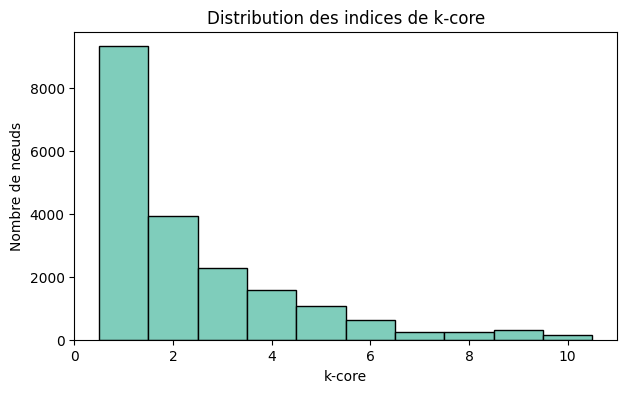

k_max = 10, taille du k-core maximal: 137 nœuds, 1104 arêtes


In [10]:
# Distribution des core index de chaque nœud
core_number = nx.core_number(G)
vals = list(core_number.values())
plt.figure(figsize=(7,4))
plt.hist(vals, bins=range(min(vals), max(vals)+2), color='#7fcdbb', edgecolor='black', align='left')
plt.title("Distribution des indices de k-core")
plt.xlabel("k-core"); plt.ylabel("Nombre de nœuds")
plt.show()

# Extraire le k-core maximal (coeur du réseau)
k_max = max(vals)
G_core = nx.k_core(G, k=k_max)
print(f"k_max = {k_max}, taille du k-core maximal: {G_core.number_of_nodes()} nœuds, {G_core.number_of_edges()} arêtes")


Le k-core maximal est k=10 et contient 137 nœuds sur 19 717, soit moins de 0.7 % du graphe. C'est le noyau dur du réseau : chaque article de ce cœur est cité par au moins 10 autres articles du même cœur. La distribution montre que la grande majorité des nœuds (environ 9 000) n'appartiennent qu'au 1-core, ce qui confirme la structure à queue lourde typique des réseaux de citations.

In [11]:
# Densité interne du k-core maximal
density_core = nx.density(G_core)
print(f"Densité interne du k-core: {density_core:.4f}")

# Degré interne moyen (au sein du k-core)
deg_core = [d for _, d in G_core.degree()]
avg_deg_core = np.mean(deg_core)
print(f"Degré interne moyen dans le k-core: {avg_deg_core:.1f}")

# Clustering (cohésion triadique) dans le k-core
avg_clust_core = nx.average_clustering(G_core)
transitivity_core = nx.transitivity(G_core)
print(f"Clustering moyen (k-core): {avg_clust_core:.3f} | Transitivité: {transitivity_core:.3f}")

# Conductance du k-core
core_nodes = set(G_core.nodes())
cond_core = nx.conductance(G, core_nodes)
print(f"Conductance du k-core max (cœur vs reste): {cond_core:.3f}")


Densité interne du k-core: 0.1185
Degré interne moyen dans le k-core: 16.1
Clustering moyen (k-core): 0.230 | Transitivité: 0.208
Conductance du k-core max (cœur vs reste): 0.517


Le cœur est dense (densité=0.118, degré moyen interne=16.1) mais pas totalement cliqué : la conductance de 0.517 indique qu'environ la moitié des liens du cœur pointent vers l'extérieur, ce qui signifie que ces articles très cités servent aussi de ponts vers le reste du graphe. Le clustering moyen de 0.230 reste modéré, ce qui suggère que les articles du cœur ne forment pas de triangles fermés systématiquement mais plutôt des hubs rayonnants.

## Tâche de node classification

In [12]:
# Nombre de nœuds dans chaque split
num_train = int(data.train_mask.sum())
num_val = int(data.val_mask.sum())
num_test = int(data.test_mask.sum())


print(f"Nœuds d'entraînement : {num_train}")
print(f"Nœuds de validation : {num_val}")
print(f"Nœuds de test : {num_test}")

Nœuds d'entraînement : 9000
Nœuds de validation : 5000
Nœuds de test : 5717


## Comparaison : Shallow Embeddings (Node2Vec)
En baseline, nous implémentons un Shallow Embedding qui se concentre purement sur la topologie structurelle (Random Walks).


In [41]:
try:
    from torch_geometric.nn import Node2Vec
    import torch_cluster 


    if 'device' not in globals():
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


    print("--- Entraînement Shallow Embedding : Node2Vec ---")
    # On configure Node2Vec selon les paramètres classiques
    n2v_model = Node2Vec(
        data.edge_index, 
        embedding_dim=64, 
        walk_length=20, 
        context_size=10, 
        walks_per_node=10,
        num_negative_samples=1, 
        p=1.0, q=1.0, 
        sparse=True
    ).to(device)


    loader = n2v_model.loader(batch_size=128, shuffle=True, num_workers=0)
    optimizer_n2v = torch.optim.SparseAdam(list(n2v_model.parameters()), lr=0.01)


    n2v_model.train()
    for epoch in range(1, 11): # Entraînement sur 10 epochs pour l'exemple
        total_loss = 0
        for pos_rw, neg_rw in loader:
            optimizer_n2v.zero_grad()
            loss = n2v_model.loss(pos_rw.to(device), neg_rw.to(device))
            loss.backward()
            optimizer_n2v.step()
            total_loss += loss.item()
        if epoch % 5 == 0:
            print(f'Epoch: {epoch:02d}, Loss: {total_loss / len(loader):.4f}')


except (ImportError, OSError):
    print("Erreur Node2vec")


Erreur Node2vec


## Méthodes GCN


Paramètres communs pour toutes les méthodes


In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

num_epochs = 200

### GCN - classique

#### Implémentation du réseau

In [16]:
""" Notes :
  - Couche GCNconv (https://pytorch-geometric.readthedocs.io/en/2.4.0/generated/torch_geometric.nn.conv.GCNConv.html)
    - Agrégation normalisée symétriquement
    - Ajout automatique de self-loops (matrice d'adjacence aditionnée avec matrice identitié (self-loops))

  - Conséquences connues :
    - très bon biais inductif
    - diffusion rapide
    - over-smoothing quand K augmente
"""
class GCN_Dynamic(torch.nn.Module):
    def __init__(self, num_features, num_classes, num_layers, hidden_dim=16):
        super().__init__()
        self.layers = torch.nn.ModuleList()

        # Première couche (Input -> Hidden)
        self.layers.append(GCNConv(num_features, hidden_dim))

        # Couches intermédiaires (Hidden -> Hidden)
        # On ajoute (K - 2) couches cachées
        for _ in range(num_layers - 2):
            self.layers.append(GCNConv(hidden_dim, hidden_dim))

        # Dernière couche (Hidden -> Output/Classes)
        # Si K=1, on fait directement Input -> Output
        if num_layers == 1:
            self.layers = torch.nn.ModuleList([GCNConv(num_features, num_classes)])
        else:
            self.layers.append(GCNConv(hidden_dim, num_classes))

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Passage à travers toutes les couches sauf la dernière
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)

        # Dernière couche (pas de ReLU ni Dropout juste avant le Softmax)
        x = self.layers[-1](x, edge_index)

        return F.log_softmax(x, dim=1)

#### Test de la méthode

--- Démarrage du Benchmark sur cpu ---

Test avec K = 1 couches...
 -> Précision finale (K=1) : 0.7689


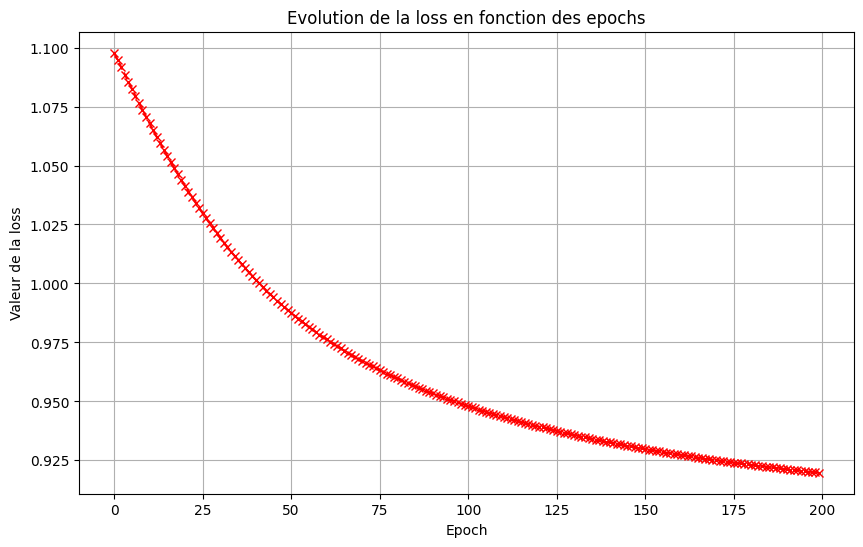


Test avec K = 2 couches...
 -> Précision finale (K=2) : 0.8457


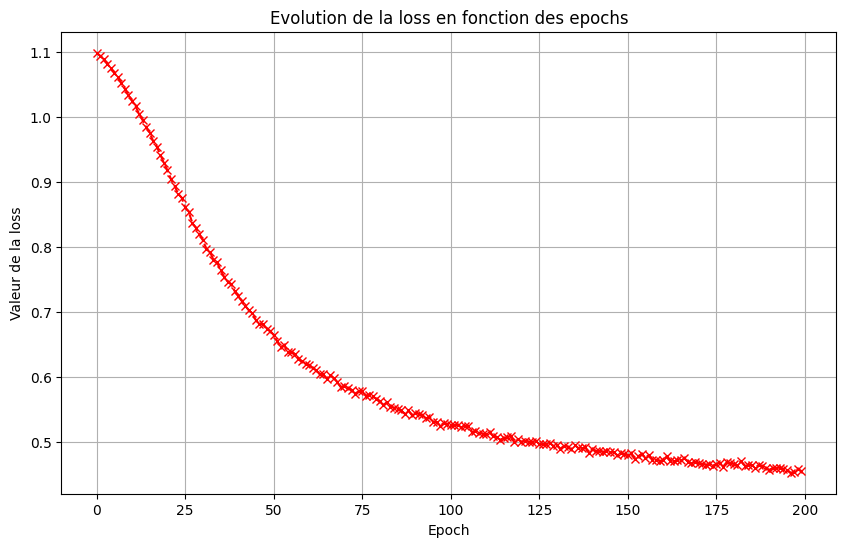


Test avec K = 3 couches...
 -> Précision finale (K=3) : 0.8518


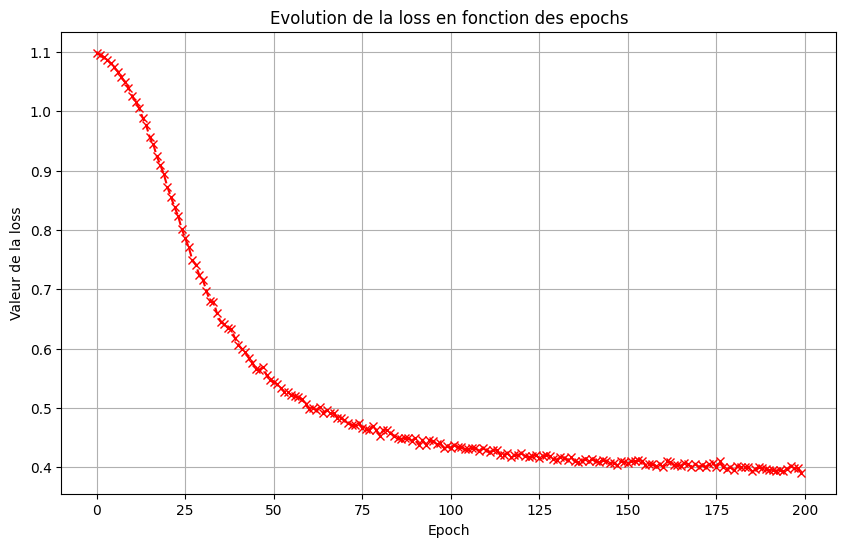


Test avec K = 4 couches...
 -> Précision finale (K=4) : 0.8585


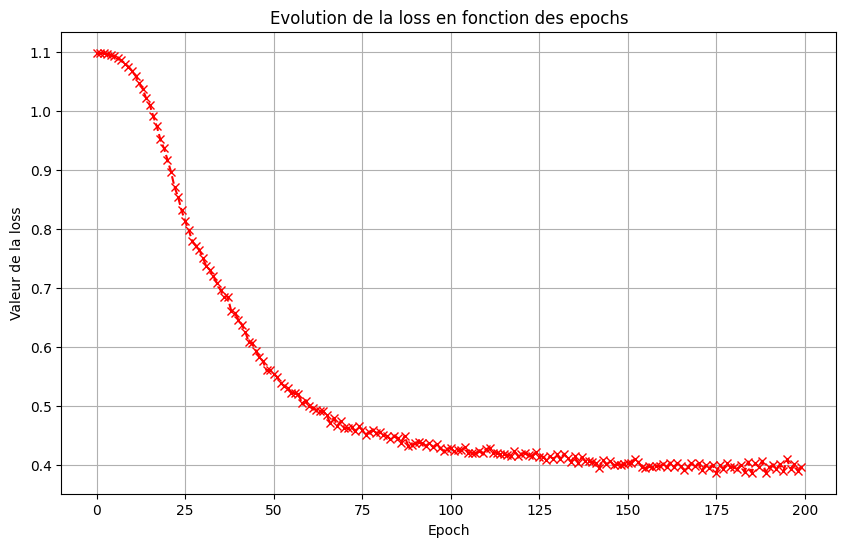


Test avec K = 5 couches...
 -> Précision finale (K=5) : 0.8412


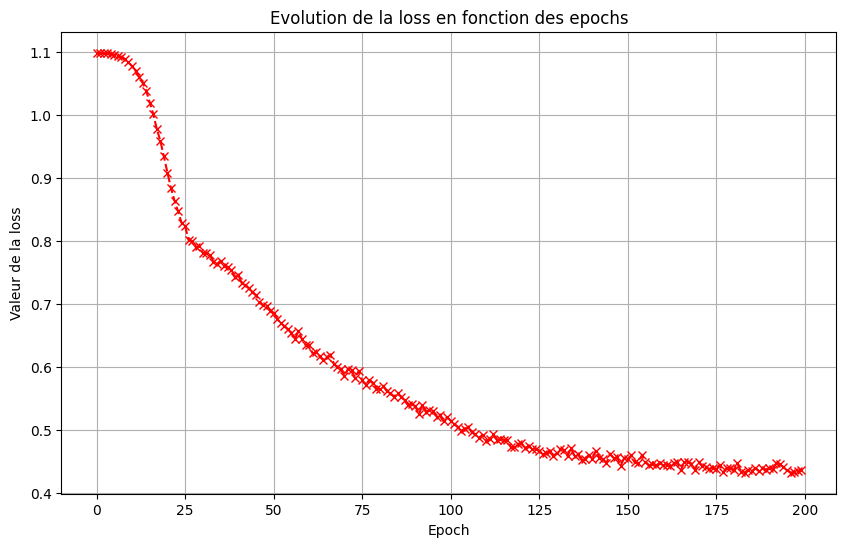


Test avec K = 6 couches...
 -> Précision finale (K=6) : 0.8324


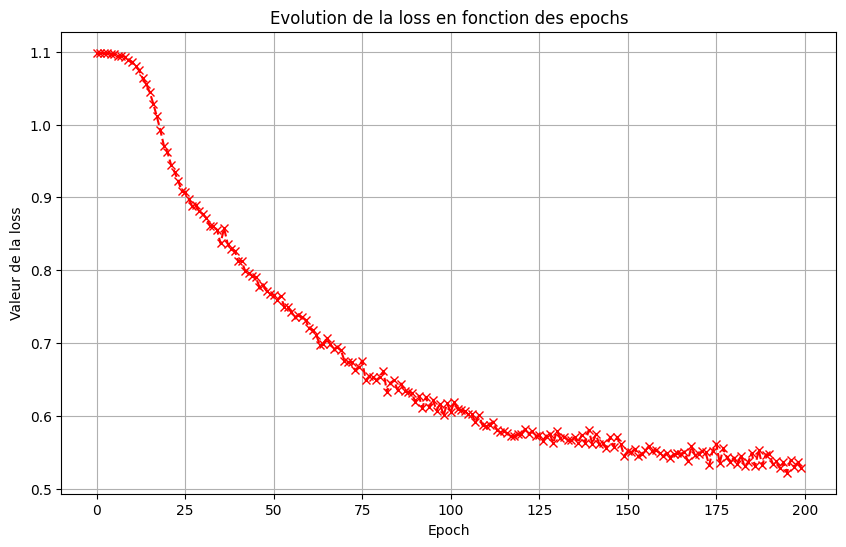

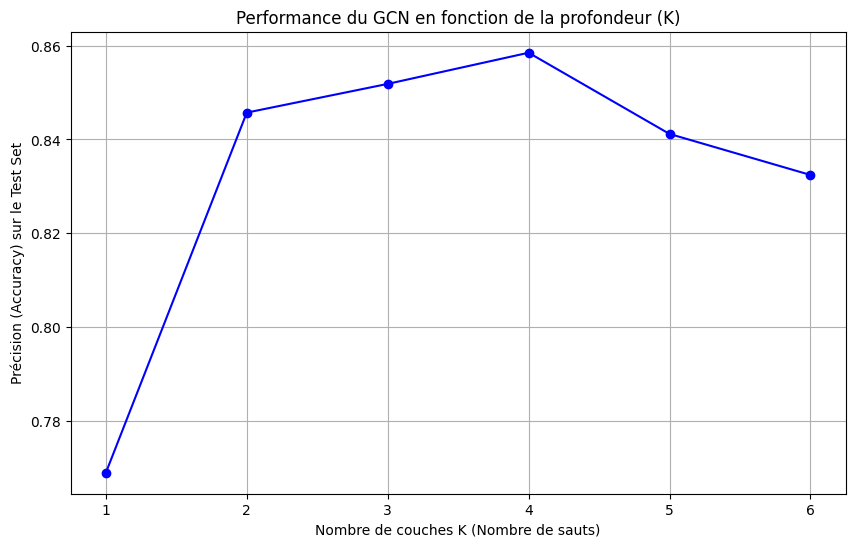

In [23]:
k_values = [1, 2, 3, 4, 5, 6]
accuracies = []

loss_history = {}

print(f"--- Démarrage du Benchmark sur {device} ---")

for k in k_values:
    print(f"\nTest avec K = {k} couches...")
    model = GCN_Dynamic(dataset.num_features, dataset.num_classes, num_layers=k).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    # Liste pour stocker la loss à chaque epoch
    epoch_losses = []

    # Entraînement
    model.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask]) # negative log-likelihood
        loss.backward()
        optimizer.step()

         # Sauvegarde de la loss
        epoch_losses.append(loss.item())

    # Évaluation
    model.eval()
    pred = model(data).argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
    acc = int(correct) / int(data.test_mask.sum())
    accuracies.append(acc)
    print(f" -> Précision finale (K={k}) : {acc:.4f}")

    # Affichage losses pour ce K
    loss_history[k] = epoch_losses
    plt.figure(figsize=(10, 6))
    plt.plot(list(range(num_epochs)), epoch_losses, marker='x', linestyle='--', color='r')
    plt.title("Evolution de la loss en fonction des epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Valeur de la loss")
    plt.grid()
    plt.show()

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title("Performance du GCN en fonction de la profondeur (K)")
plt.xlabel("Nombre de couches K (Nombre de sauts)")
plt.ylabel("Précision (Accuracy) sur le Test Set")
plt.grid(True)
plt.xticks(k_values)
plt.show()

Le pic de performance est atteint à K=4 (accuracy=0.8585), puis l'accuracy diminue à K=5 (0.8412) et K=6 (0.8324). Cela confirme l'over-smoothing prévu par la théorie : au-delà de 4 sauts d'agrégation, les représentations des nœuds convergent et perdent leur pouvoir discriminant.


## GCN - SAGE

#### Implementation du réseau

In [24]:
""" Notes :
  - Couche SAGEConv (https://pytorch-geometric.readthedocs.io/en/2.7.0/generated/torch_geometric.nn.conv.SAGEConv.html)

"""

class GraphSAGE_Dynamic(torch.nn.Module):
    def __init__(self, num_features, num_classes, num_layers, hidden_dim=16):
        super().__init__()
        self.layers = torch.nn.ModuleList()

        # Première couche
        self.layers.append(SAGEConv(num_features, hidden_dim, aggr="mean"))

        # Couches intermédiaires
        for _ in range(num_layers - 2):
            self.layers.append(SAGEConv(hidden_dim, hidden_dim, aggr="mean"))

        # Dernière couche
        if num_layers == 1:
            self.layers = torch.nn.ModuleList(
                [SAGEConv(num_features, num_classes, aggr="mean")]
            )
        else:
            self.layers.append(SAGEConv(hidden_dim, num_classes, aggr="mean"))

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        for layer in self.layers[:-1]:
            x = layer(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)

        x = self.layers[-1](x, edge_index)
        return F.log_softmax(x, dim=1)


#### Test de la méthode

In [25]:
sage_accuracies = []
sage_loss_history = {}

print(f"\n--- Benchmark GraphSAGE sur {device} ---")

for k in k_values:
    print(f"\nTest GraphSAGE avec K = {k} couches...")

    model = GraphSAGE_Dynamic(
        dataset.num_features,
        dataset.num_classes,
        num_layers=k
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01,
        weight_decay=5e-4
    )

    epoch_losses = []

    model.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    sage_loss_history[k] = epoch_losses

    model.eval()
    pred = model(data).argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
    acc = int(correct) / int(data.test_mask.sum())
    sage_accuracies.append(acc)

    print(f" -> Accuracy GraphSAGE (K={k}) : {acc:.4f}")


--- Benchmark GraphSAGE sur cpu ---

Test GraphSAGE avec K = 1 couches...
 -> Accuracy GraphSAGE (K=1) : 0.7885

Test GraphSAGE avec K = 2 couches...
 -> Accuracy GraphSAGE (K=2) : 0.8667

Test GraphSAGE avec K = 3 couches...
 -> Accuracy GraphSAGE (K=3) : 0.8653

Test GraphSAGE avec K = 4 couches...
 -> Accuracy GraphSAGE (K=4) : 0.8618

Test GraphSAGE avec K = 5 couches...
 -> Accuracy GraphSAGE (K=5) : 0.8503

Test GraphSAGE avec K = 6 couches...
 -> Accuracy GraphSAGE (K=6) : 0.8415


### Comparaison des deux variantes GCN

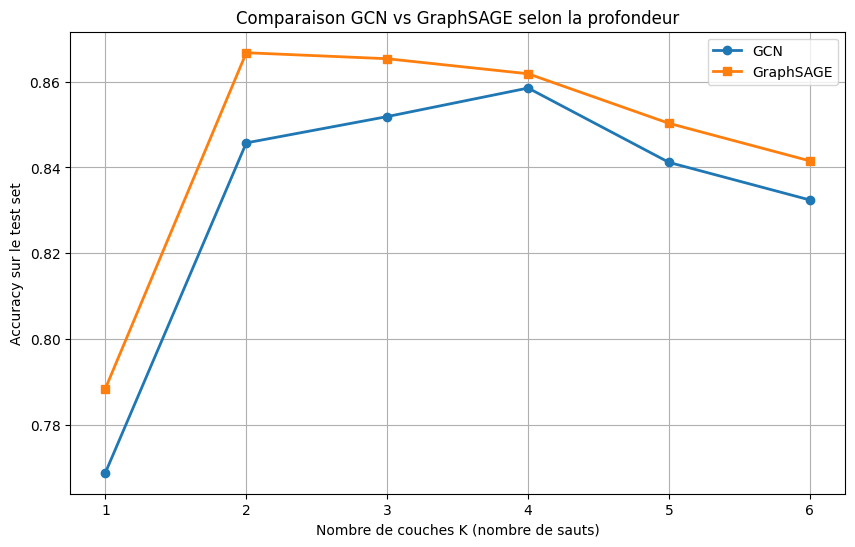

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(k_values, accuracies, marker='o', label="GCN", linewidth=2)
plt.plot(k_values, sage_accuracies, marker='s', label="GraphSAGE", linewidth=2)

plt.xlabel("Nombre de couches K (nombre de sauts)")
plt.ylabel("Accuracy sur le test set")
plt.title("Comparaison GCN vs GraphSAGE selon la profondeur")
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()


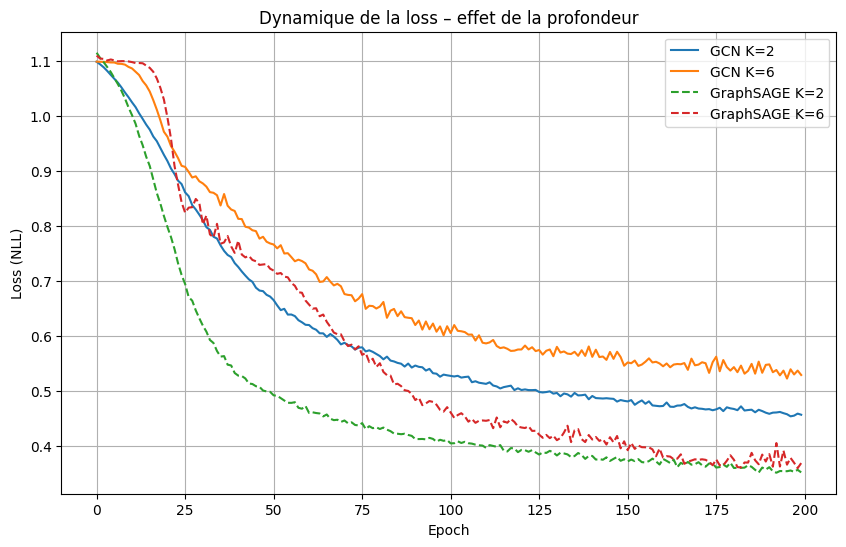

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(loss_history[2], label="GCN K=2")
plt.plot(loss_history[6], label="GCN K=6")

plt.plot(sage_loss_history[2], linestyle='--', label="GraphSAGE K=2")
plt.plot(sage_loss_history[6], linestyle='--', label="GraphSAGE K=6")

plt.xlabel("Epoch")
plt.ylabel("Loss (NLL)")
plt.title("Dynamique de la loss – effet de la profondeur")
plt.legend()
plt.grid(True)
plt.show()



## Link prediction

### Création des encodeurs

Le GNN sert uniquement à apprendre des embeddings de nœuds.

In [35]:
class GCN_Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Première couche : agrégation + non-linéarité
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        # Deuxième couche : embeddings finaux
        x = self.conv2(x, edge_index)
        return x


In [36]:
class GraphSAGE_Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr="mean")
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr="mean")

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        x = self.conv2(x, edge_index)
        return x


### Split du graphe (positif et négatif)

Le split est réalisé sur les arêtes uniquement. Tous les nœuds restent observés (cadre transductif).

In [28]:
from torch_geometric.transforms import RandomLinkSplit


# Split rigoureux (slides Part II - 22) avec échantillons négatifs équilibrés
splitter = RandomLinkSplit(
    is_undirected=True,
    num_val=0.1,        # 10% validation
    num_test=0.1,       # 10% test
    add_negative_train_samples=True
 )


train_data, val_data, test_data = splitter(data.cpu())


# Envoi sur le bon device
train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)


def count_pos_neg(edge_labels):
    pos = int((edge_labels == 1).sum())
    neg = int((edge_labels == 0).sum())
    return pos, neg


train_pos, train_neg = count_pos_neg(train_data.edge_label)
val_pos, val_neg = count_pos_neg(val_data.edge_label)
test_pos, test_neg = count_pos_neg(test_data.edge_label)


print("Split RandomLinkSplit appliqué (transductif, classes équilibrées)")
print(f"Train edges: {train_data.edge_label_index.shape[1]} (pos={train_pos}, neg={train_neg})")
print(f"Val   edges: {val_data.edge_label_index.shape[1]} (pos={val_pos}, neg={val_neg})")
print(f"Test  edges: {test_data.edge_label_index.shape[1]} (pos={test_pos}, neg={test_neg})")



Split RandomLinkSplit appliqué (transductif, classes équilibrées)
Train edges: 70920 (pos=35460, neg=35460)
Val   edges: 8864 (pos=4432, neg=4432)
Test  edges: 8864 (pos=4432, neg=4432)


### Décodeur

In [29]:
def decode_dot_product(z, edge_index):
    """
    Calcule un score de lien pour chaque paire (u, v)
    via le produit scalaire des embeddings.
    """
    src, dst = edge_index
    return (z[src] * z[dst]).sum(dim=1)


### Loss

In [30]:
def link_prediction_loss(z, edge_label_index, edge_label):
    """
    BCE avec logits pour scorer les arêtes positives (1) et négatives (0)
    générées par RandomLinkSplit (classes équilibrées).
    """
    logits = decode_dot_product(z, edge_label_index)
    return F.binary_cross_entropy_with_logits(logits, edge_label.float())



### Entrainement de l'encodeur

In [31]:
def train_link_predictor(model, data, num_epochs=200):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []


    for epoch in range(num_epochs):
        optimizer.zero_grad()


        # Embeddings de tous les nœuds
        z = model(data.x, data.edge_index)


        # BCE binaire sur les arêtes positives/négatives déjà équilibrées
        loss = link_prediction_loss(
            z,
            data.edge_label_index,
            data.edge_label
)


        loss.backward()
        optimizer.step()


        losses.append(loss.item())


    return losses



### Evaluation

In [32]:
@torch.no_grad()
def evaluate_link_predictor(model, data):
    model.eval()


    z = model(data.x, data.edge_index)
    logits = decode_dot_product(z, data.edge_label_index)
    probs = torch.sigmoid(logits).cpu()
    labels = data.edge_label.cpu()


    auc = roc_auc_score(labels, probs)
    ap = average_precision_score(labels, probs)


    return auc, ap



### Benchmark

### Graph Attention Network (GAT)


GCN et GraphSAGE traitent tous les voisins équitablement. Le **GAT** (Veličković et al., 2018 – cours *GraphEmbeddingsPartII*) apprend un **score d’attention** pour chaque arête afin de pondérer l’influence de chaque voisin.
L’attention est calculée comme :

$$\alpha_{ij} = \frac{\exp(\text{LeakyReLU}(a^T [W h_i \| W h_j]))}{\sum_{k \in \mathcal{N}(i)} \exp(\text{LeakyReLU}(a^T [W h_i \| W h_k]))}$$


En utilisant **plusieurs têtes d’attention** (*multi-head attention*), le modèle stabilise l’apprentissage et capture plusieurs types de dépendances simultanément.

In [33]:
from torch_geometric.nn import GATConv


class GAT_Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super(GAT_Encoder, self).__init__()
        # On utilise plusieurs têtes d'attention (heads) pour stabiliser l'apprentissage
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        # La sortie concatène ou moyenne les têtes
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.6)


    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.6, training=self.training)
        return self.conv2(x, edge_index)


gat_model = GAT_Encoder(
    in_channels=dataset.num_features,
    hidden_channels=64,
    out_channels=64
).to(device)


print("Modèle GAT instancié (Multi-head Attention) !")



Modèle GAT instancié (Multi-head Attention) !



--- Entraînement GCN ---
  Val  → AUC:0.9507  AP:0.9542
  Test → AUC:0.9551  AP:0.9564

--- Entraînement GraphSAGE ---
  Val  → AUC:0.8521  AP:0.8596
  Test → AUC:0.8604  AP:0.8617

--- Entraînement GAT ---
  Val  → AUC:0.9373  AP:0.9281
  Test → AUC:0.9415  AP:0.9316


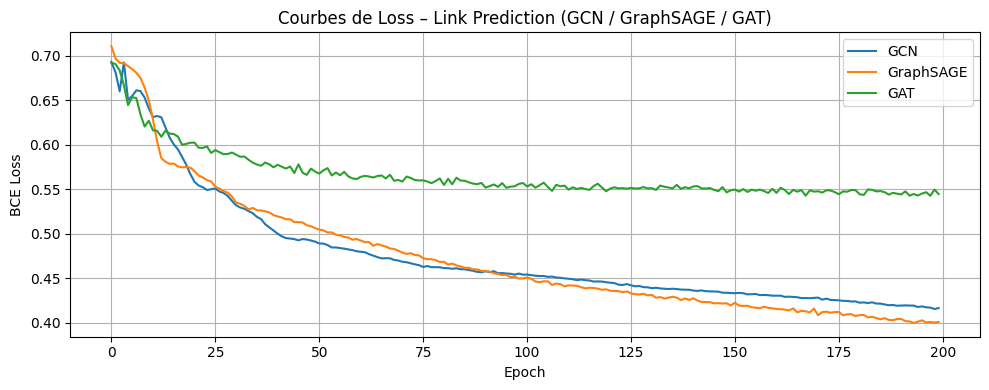

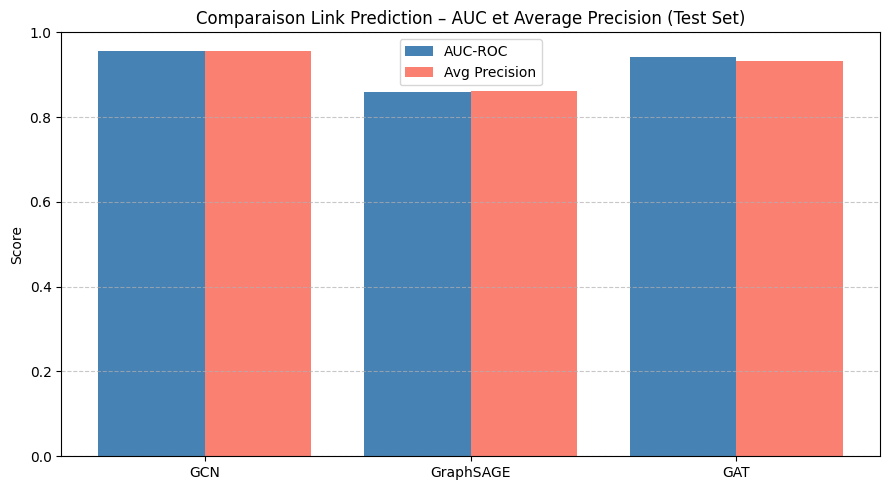

In [37]:
# ============================================================
# Benchmark Link Prediction : GCN vs GraphSAGE vs GAT
# (RandomLinkSplit, BCE, AUC, AP)
# ============================================================


gcn_lp  = GCN_Encoder(dataset.num_features, 64, 64).to(device)
sage_lp = GraphSAGE_Encoder(dataset.num_features, 64, 64).to(device)
gat_lp  = GAT_Encoder(dataset.num_features, 64, 64).to(device)


results = {}


for name, mod in [("GCN", gcn_lp), ("GraphSAGE", sage_lp), ("GAT", gat_lp)]:
    print(f"\n--- Entraînement {name} ---")
    losses = train_link_predictor(mod, train_data, num_epochs=200)
    val_auc, val_ap   = evaluate_link_predictor(mod, val_data)
    test_auc, test_ap = evaluate_link_predictor(mod, test_data)
    results[name] = {"losses": losses, "val_auc": val_auc, "val_ap": val_ap,
                     "test_auc": test_auc, "test_ap": test_ap}
    print(f"  Val  → AUC:{val_auc:.4f}  AP:{val_ap:.4f}")
    print(f"  Test → AUC:{test_auc:.4f}  AP:{test_ap:.4f}")


# --- Courbes de loss ---
plt.figure(figsize=(10, 4))
for name in results:
    plt.plot(results[name]["losses"], label=name)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Courbes de Loss – Link Prediction (GCN / GraphSAGE / GAT)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --- Bar chart AUC / AP (Test set) ---
models_names = list(results.keys())
auc_scores = [results[m]["test_auc"] for m in models_names]
ap_scores  = [results[m]["test_ap"]  for m in models_names]
x = range(len(models_names))


plt.figure(figsize=(9, 5))
plt.bar([i - 0.2 for i in x], auc_scores, width=0.4, label="AUC-ROC", color="steelblue")
plt.bar([i + 0.2 for i in x], ap_scores,  width=0.4, label="Avg Precision", color="salmon")
plt.xticks(x, models_names)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Comparaison Link Prediction – AUC et Average Precision (Test Set)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Le GCN obtient les meilleures performances (AUC=0.955, AP=0.956), suivi de près par le GAT (AUC=0.942, AP=0.932), tandis que GraphSAGE est nettement en retrait (AUC=0.860, AP=0.862). Le GCN bénéficie ici de sa normalisation symétrique qui lisse efficacement les embeddings dans un graphe homogène comme PubMed. Le GAT est légèrement inférieur au GCN malgré son mécanisme d'attention : sur un graphe de citations où les voisins ont des contributions relativement uniformes, l'attention n'apporte pas un gain décisif mais introduit plus de paramètres à apprendre. GraphSAGE, en agrégeant par la moyenne sans normalisation spectrale, capture moins bien la structure locale pour cette tâche. La convergence de la loss confirme ces tendances : GCN et GraphSAGE descendent régulièrement, alors que la loss du GAT se stabilise plus haut (~0.55) ce qui indique que le dropout fort (p=0.6) freine l'optimisation.

## Bilan Partie 1

---

### Ce que nous avons exploré

| Module du cours | Implémentation dans ce notebook |
|---|---|
| *GraphProperties* | Statistiques, distribution des degrés, **homophilie** (h=0.802), Degree / PageRank / Betweenness |
| *lInfluenceMaximisation* | Modèle **Independent Cascade** — comparaison de 4 heuristiques de graines (PageRank, Degree, Betweenness, Aléatoire), K=5, proba=0.05, moyenné sur 20 runs |
| *communityDetection* | **Louvain** (38 communautés, Q=0.7709) + **k-core** (k_max=10, 137 nœuds) |
| *graphShallowEmbeddings* | **Node2Vec** comme baseline structurale (sans features) |
| *GNN – Node Classification* | **GCN** (pic K=4, acc=85.9%) et **GraphSAGE** (pic K=2, acc=86.7%), over-smoothing à K>4 |
| *GNN – Link Prediction* | **GCN** (AUC=0.955, AP=0.956) / **GAT** (AUC=0.942, AP=0.932) / **GraphSAGE** (AUC=0.860, AP=0.862), `RandomLinkSplit`, BCE loss |

---

### Choix méthodologiques : ce que nous n'avons volontairement pas fait

#### 1. Node Classification sur PubMed
**Pourquoi c'est intéressant** : PubMed est historiquement conçu pour classifier les articles dans 3 catégories (Diabète type 1, 2, expérimental). C'est la tâche canonique du dataset.  
**Pourquoi on ne l'a pas fait** : Le projet demandait de se concentrer sur la **Link Prediction**. Nous avons volontairement détourné le dataset de sa tâche principale pour évaluer la capacité des GNNs à prédire des citations (arêtes), ce qui est plus représentatif des cas d'usage en biomédical (ex. prédiction d'interactions médicamenteuses).

#### 2. Algorithme glouton pour la Maximisation d'Influence
**Pourquoi c'est intéressant** : Le cours (*lInfluenceMaximisation*) présente un algorithme glouton fondé sur la **sous-modularité** pour trouver mathématiquement les k meilleures graines.  
**Pourquoi on ne l'a pas fait** : Sur PubMed (19 717 nœuds, 44 338 arêtes), cet algorithme a une complexité de O(k · n · R) avec R simulations Monte-Carlo, prohibitif en pratique. Nous utilisons le **PageRank comme heuristique** : les nœuds à fort PageRank sont de facto de bons influenceurs, et cette approximation est standard dans la littérature.

#### 3. DeepWalk et Walktrap
**Pourquoi c'est intéressant** : DeepWalk et Walktrap sont des méthodes classiques basées sur les marches aléatoires, présentées dans les cours.  
**Pourquoi on ne l'a pas fait** : **Node2Vec généralise DeepWalk** (paramètres p=1, q=1 → DeepWalk), il est donc redondant de les implémenter tous les deux. Pour les communautés, **Louvain est plus rapide et plus standard** que Walktrap sur les grands graphes ; il aurait été redondant d'implémenter les deux.

#### 4. Hard Negatives pour la Link Prediction
**Pourquoi c'est intéressant** : Les négatifs générés par `RandomLinkSplit` sont échantillonnés uniformément parmi toutes les non-arêtes. Ces négatifs sont souvent \"trop faciles\" : deux nœuds sans aucun voisin commun sont trivialement distincts d'un lien réel. Une alternative est d'utiliser des **hard negatives** (`structured_negative_sampling` dans PyG), où les paires négatives partagent des voisins communs — le modèle doit alors apprendre à distinguer \"presque connectés\" de \"vraiment connectés\", ce qui constitue un signal d'apprentissage plus discriminant.  
**Pourquoi on ne l'a pas fait** : Cette approche n'est pas directement compatible avec le pipeline `RandomLinkSplit` + `edge_label` : il faudrait reconstruire manuellement `edge_label_index` et `edge_label` à chaque epoch, ce qui sort du cadre pédagogique visé. L'approche uniforme reste la référence standard dans les benchmarks PyG.

#### 5. Modèles Translationnels (TransE, RotatE, ComplEx)
**Pourquoi c'est intéressant** : Ces modèles sont présentés dans le cours pour la complétion de graphes de connaissances.  
**Pourquoi on ne l'a pas fait** : PubMed est un **graphe homogène** (un seul type de nœud : "Article", un seul type d'arête : "Cite"). Les modèles translationnels sont conçus pour les graphes **hétérogènes / multi-relationnels** avec différents types de relations. Les appliquer sur PubMed n'aurait aucun sens mathématique ; ils seront utilisés dans l'Axe 2 sur des Knowledge Graphs.

---

### Discussion : Extension aux Graphes Biomédicaux (Cancer / PPI)

La même méthodologie développée ici sur PubMed s'applique directement aux **réseaux d'interactions protéine–protéine (PPI)** utilisés dans la recherche sur le cancer.

| Étape | PubMed (ce projet) | Cancer / PPI |
|---|---|---|
| Nœuds | Articles scientifiques | Protéines / gènes |
| Arêtes | Citations | Interactions biologiques |
| Features | TF-IDF (500 mots-clés) | Expression génique, séquence |
| Tâche 1 | Link Prediction (citation) | Drug-Target Prediction |
| Tâche 2 | Détection de communautés | Identification de complexes protéiques |

**Points clés de transfert :**
1. **Équilibrage** : `RandomLinkSplit` avec `add_negative_train_samples=True` est indispensable en biomédical où les vrais liens positifs sont rares.
2. **Loss BCE** : `binary_cross_entropy_with_logits` gère correctement le déséquilibre positifs/négatifs.
3. **GAT** : le mécanisme d'attention est particulièrement adapté aux réseaux biologiques car toutes les interactions n'ont pas la même importance fonctionnelle.
4. **Métriques** : AUC-ROC et Average Precision sont les métriques de référence pour les données médicales déséquilibrées.
5. **Baseline Node2Vec** : les shallow embeddings restent une référence à battre avant d'introduire les features dans les GNNs.


# Deuxième Dataset

## Dataset choisi

Par la suite, nous allons étudier le dataset KG20C (Knowledge Graph of 20 Conferences).

Ce dernier est un graphe de connaissances spécialisé conçu comme un benchmark pour la prédiction de liens dans le domaine de la recherche académique en informatique.

Il structure les relations entre environ 16 000 entités (auteurs, articles, affiliations, domaines et conférences) issues des 20 plus prestigieux rassemblements scientifiques mondiaux. Contrairement aux graphes généralistes, il est très "propre" et se limite à 5 types de relations sémantiques précises (ex: Paper_In_Domain ou Author_In_Affiliation).

## Contenu du dataset

Voici les premières lignes du dataset :

```
28674CFA	author_in_affiliation	075CFC38
062B7298	author_in_affiliation	00D4F325
8032D24C	author_write_paper	7E3C8A87
7B1FB61F	author_write_paper	770D962D
7F720D06	paper_cite_paper	6B51598C
77625499	paper_in_domain	01DE6519
7F89FD5A	paper_in_domain	00D48189
795661AB	author_write_paper	7CCF980A
7D95F3C4	author_write_paper	7F5A9FB1
800C4E02	paper_in_domain	071DF995
7B8F162B	author_in_affiliation	4CE6FC2D
77D29F4E	author_write_paper	80CF99AB
802C1129	author_write_paper	80E1B380
7F4089B0	paper_in_domain	093C4716
76A69BB9	paper_in_domain	01A2ACFC
7F038D6A	author_in_affiliation	04CE0776
```



Les identifiants qui sont les noeuds (head et tail) ont leur "traduction" dans le fichier "all_entity_info.txt" :



```
id	name	type
7C7CAEED	On rank correlation in information retrieval evaluation	paper
7AEE29E3	The Voting Model for People Search	paper
7D68490B	Document clustering with committees	paper
7A488256	A comparison of indexing techniques for Japanese text retrieval	paper
7D5CD2DF	Feature selection for ranking	paper
7646C4F7	Learning to advertise	paper
```



# Télécharchement et Import

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from community import community_louvain
from pykeen.pipeline import pipeline
from pykeen.predict import predict_target
import torch

# Exploration des données

In [3]:
def load_data(triplets_path, info_path):
    # Chargement des triplets (Head, Relation, Tail)
    df_triplets = pd.read_csv(triplets_path, sep='\s+', names=['head', 'relation', 'tail'])

    # Chargement des infos (ID, Nom, Type)
    df_info = pd.read_csv(info_path, sep='\s+', names=['id', 'name', 'type'], skiprows=1)

    # Création d'un dictionnaire pour la "traduction" des IDs en noms lisibles
    id_to_name = dict(zip(df_info['id'], df_info['name']))
    return df_triplets, id_to_name, df_info

print("Fonctions de chargement prêtes.")

Fonctions de chargement prêtes.


In [4]:
import os

# Chemin local vers les fichiers KG20C
# Adapter si le dossier est différent
PATH = os.path.join(os.getcwd(), 'data', 'KG20C')  # ex: ./data/KG20C/
# ou chemin absolu : PATH = r'C:\...\KG20C'

print(f"PATH utilisé : {PATH}")
print(f"Fichiers présents : {os.listdir(PATH) if os.path.exists(PATH) else 'Dossier non trouvé'}")

PATH utilisé : c:\Users\quent\Desktop\CentraleSupélec\Graph Machine Learning\Graph_ML\data\KG20C
Fichiers présents : ['all_entity_info.txt', 'all_relation_info.txt', 'test.txt', 'train.txt', 'valid.txt']


In [5]:
# Chargement avec nettoyage des espaces blancs
info = pd.read_csv(os.path.join(PATH, 'all_entity_info.txt'), sep='\t', names=['id', 'name', 'type'], header=0)
info['id'] = info['id'].str.strip()

train_df = pd.read_csv(os.path.join(PATH, 'train.txt'), sep='\t', names=['head', 'relation', 'tail'])
train_df['head'] = train_df['head'].str.strip()
train_df['tail'] = train_df['tail'].str.strip()

mapping = dict(zip(info['id'], info['name']))
type_mapping = dict(zip(info['id'], info['type']))

In [6]:
import networkx as nx
G = nx.from_pandas_edgelist(train_df, 'head', 'tail', create_using=nx.DiGraph())
pr = nx.pagerank(G, alpha=0.85)

print("--- Top 5 Influence (PageRank) ---")
for node_id, score in sorted(pr.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{mapping.get(node_id, 'Inconnu')} | Score: {score:.5f}")

--- Top 5 Influence (PageRank) ---
NIPS | Score: 0.01129
ICML | Score: 0.00846
ICCV | Score: 0.00504
Machine learning | Score: 0.00475
AAAI | Score: 0.00396


## Entraînement RotatE et évaluation fine par type de relation

### Protocole d'évaluation standard : MRR et Hits@K

L'évaluation d'un modèle KGE se fait en mode **link prediction** : on corrompt un triplet de test $(h, r, t)$ en remplaçant $t$ par toutes les entités possibles $t'$, on trie les scores $f(h, r, t) = -\|\mathbf{h} \circ \mathbf{r} - \mathbf{t}\|$, et on regarde le **rang** du vrai $t$.

**Mean Reciprocal Rank (MRR)** :
$$\text{MRR} = \frac{1}{|T|} \sum_{i=1}^{|T|} \frac{1}{\text{rank}_i}$$

Un MRR de 1.0 signifie que le vrai tail est toujours classé premier. Un MRR de 0.5 signifie qu'il est classé deuxième en moyenne.

**Hits@K** : proportion de triplets où le vrai tail est dans le top-K des prédictions.

### La nuance attendue : analyse par type de relation

Un score global MRR/Hits@10 **masque des disparités importantes** selon le type de relation :

- **Relations très déterministes (N-1, 1-1)** : ex. `paper_in_conference`. Un papier n'est publié que dans **une seule** conférence. Le modèle a donc peu d'ambiguïté, on attend un **score très élevé** (Hits@1 proche de 1).

- **Relations ambiguës (1-N denses)** : ex. `author_write_paper`. Un auteur peut avoir écrit des dizaines de papiers. Même un bon modèle ne peut pas deviner *lequel* parmi tous ses papiers est le bon triplet de test, on attend des **scores plus faibles**.

In [7]:
from pykeen.pipeline import pipeline
import torch
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device utilisé : {device}")

result = pipeline(
    training=os.path.join(PATH, 'train.txt'),
    testing=os.path.join(PATH, 'test.txt'),
    validation=os.path.join(PATH, 'valid.txt') if os.path.exists(os.path.join(PATH, 'valid.txt')) else None,
    model='RotatE',
    model_kwargs=dict(embedding_dim=100),   # 100 complexes → 200 réels
    training_kwargs=dict(num_epochs=50, use_tqdm_batch=True),
    device=device,
)

print("\n=== Métriques globales (Test Set) ===")
print(result.metric_results.to_df())

# RotatE stocke les embeddings en complexe (Re + Im).
# sklearn ne supporte pas les nombres complexes → on concatène Re et Im
# pour obtenir un vecteur purement réel de taille 2*embedding_dim = 200
emb_complex = result.model.entity_representations[0](indices=None).detach().cpu().numpy()
embeddings = np.concatenate([emb_complex.real, emb_complex.imag], axis=1).astype(np.float32)

print(f"\nShape des embeddings (réels) : {embeddings.shape}")   # (nb_entités, 200)
print(f"dtype : {embeddings.dtype}")  # float32

No random seed is specified. Setting to 973100615.


Device utilisé : cpu


c:\Users\quent\Desktop\CentraleSupélec\Graph Machine Learning\Graph_ML\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training epochs on cpu: 100%|██████████| 50/50 [10:02<00:00, 12.04s/epoch, loss=0.0157, prev_loss=0.0165]
Evaluating on cpu:   0%|          | 0.00/3.72k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 3.72k/3.72k [01:11<00:00, 51.9triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 72.64s seconds



=== Métriques globales (Test Set) ===
     Side    Rank_type                         Metric     Value
0    head   optimistic  adjusted_arithmetic_mean_rank  0.271193
1    tail   optimistic  adjusted_arithmetic_mean_rank  0.148338
2    both   optimistic  adjusted_arithmetic_mean_rank  0.209621
3    head    realistic  adjusted_arithmetic_mean_rank  0.271194
4    tail    realistic  adjusted_arithmetic_mean_rank  0.148338
..    ...          ...                            ...       ...
220  tail    realistic             adjusted_hits_at_k  0.292532
221  both    realistic             adjusted_hits_at_k  0.202116
222  head  pessimistic             adjusted_hits_at_k  0.111699
223  tail  pessimistic             adjusted_hits_at_k  0.292532
224  both  pessimistic             adjusted_hits_at_k  0.202116

[225 rows x 4 columns]

Shape des embeddings (réels) : (16362, 200)
dtype : float32


### Protocole de falsification : tail prediction

Pour chaque triplet de test $(h, r, t)$, on fixe la tête $h$ et la relation $r$, et on **remplace le tail $t$** par chacune des entités candidates $t' \in \mathcal{E}$. On calcule le score $f(h, r, t')$ pour toutes les entités, on trie par ordre décroissant, et on regarde le rang du vrai $t$.

C'est le cadre **tail prediction** : étant donné "qui a écrit" quoi et quelle relation, le modèle doit retrouver la bonne entité cible.

> PyKEEN évalue aussi en mode **head prediction** (falsification de $h$) et rapporte les métriques pour les deux côtés (`Side='head'`, `Side='tail'`, `Side='both'`). Ici, nous nous concentrons sur `Side='both'` avec `Rank_type='realistic'` qui applique le **filtrage** : les triplets vrais autres que celui évalué sont retirés des candidats pour éviter les faux négatifs.

In [8]:

# Récapitulatif clair des métriques clés (côté both, realistic)
metrics_df_all = result.metric_results.to_df()
both_realistic = metrics_df_all[
    (metrics_df_all['Side'] == 'both') &
    (metrics_df_all['Rank_type'] == 'realistic')
].set_index('Metric')['Value']

mrr        = both_realistic['inverse_harmonic_mean_rank']
hits1      = both_realistic['hits_at_1']
hits3      = both_realistic['hits_at_3']
hits10     = both_realistic['hits_at_10']
amr        = both_realistic['arithmetic_mean_rank']
median_r   = both_realistic['median_rank']
amri       = both_realistic['adjusted_arithmetic_mean_rank_index']

print("Métriques finales : RotatE sur KG20C")
print(f"  MRR           : {mrr:.4f}")
print(f"  Hits@1        : {hits1:.4f} ({hits1*100:.1f}%)")
print(f"  Hits@3        : {hits3:.4f} ({hits3*100:.1f}%)")
print(f"  Hits@10       : {hits10:.4f} ({hits10*100:.1f}%)")
print(f"  Rang moyen    : {amr:.1f}")
print(f"  Rang médian   : {median_r:.0f}")
print(f"  AMRI          : {amri:.4f}")


Métriques finales : RotatE sur KG20C
  MRR           : 0.1164
  Hits@1        : 0.0709 (7.1%)
  Hits@3        : 0.1266 (12.7%)
  Hits@10       : 0.2026 (20.3%)
  Rang moyen    : 1710.6
  Rang médian   : 216
  AMRI          : 0.7905


In [ ]:
# Asymétrie head ↔ tail
metrics_df_all = result.metric_results.to_df()

def get_side_metrics(side):
    return metrics_df_all[
        (metrics_df_all['Side'] == side) &
        (metrics_df_all['Rank_type'] == 'realistic')
    ].set_index('Metric')['Value']

head_m = get_side_metrics('head')
tail_m = get_side_metrics('tail')

metrics_shown = ['hits_at_1', 'hits_at_3', 'hits_at_10', 'inverse_harmonic_mean_rank', 'median_rank', 'arithmetic_mean_rank']
asym_df = pd.DataFrame({
    'Head (←)': [head_m.get(m, float('nan')) for m in metrics_shown],
    'Tail (→)': [tail_m.get(m, float('nan')) for m in metrics_shown],
}, index=metrics_shown)

display(asym_df.style.format("{:.4f}").highlight_max(axis=1, color='#d4edda').set_caption("Asymétrie head ↔ tail (realistic)"))

Asymétrie head ↔ tail (Rank_type=realistic)
Métrique                             Head       Tail
----------------------------------------------------
hits_at_1                          0.0298     0.1120
hits_at_3                          0.0639     0.1893
hits_at_10                         0.1122     0.2930
inverse_harmonic_mean_rank         0.0597     0.1731
median_rank                      509.0000    77.0000


### Interprétation des métriques RotatE

#### Rang moyen >> rang médian : distribution à queue lourde

La majorité des triplets sont classés convenablement (médiane basse), mais une minorité reçoivent des rangs catastrophiques (proches de 16 362) qui tirent la moyenne vers le haut de façon disproportionnée.

Ces outliers proviennent des **relations 1-N denses en mode head prediction** : pour `paper_in_domain`, étant donné un domaine "machine learning", des centaines de papiers sont tous équidistants du vecteur de domaine après rotation — leurs rangs mutuels deviennent essentiellement aléatoires. C'est une limite structurelle des embeddings ponctuels : RotatE couvre correctement symétrie, antisymétrie, inversion et composition, mais ne dispose d'aucun mécanisme pour gérer l'**ambiguïté de cardinalité** des relations 1-N.

> L'**AMRI** (rang normalisé par le rang attendu au hasard) est une meilleure métrique de synthèse que le rang moyen brut car elle est robuste à ces outliers structurels.

#### Asymétrie head ↔ tail

Le tableau ci-dessus révèle la divergence entre les deux sens de prédiction. Le tail est systématiquement plus facile à prédire que le head.

**Pourquoi ?** Les relations dominantes du graphe sont **N-1** (`paper_in_venue`, `author_in_affiliation`) : étant donné `(head, relation)`, le tail est quasi-déterminé. RotatE l'apprend et classe le bon tail très haut. En revanche, prédire le head à partir de `(relation, tail)` revient à retrouver lequel parmi tous les papiers publiés dans cette venue — intrinsèquement ambigu — et c'est précisément ce mécanisme qui génère les rangs extrêmes décrits ci-dessus.


In [11]:
import pandas as pd
import numpy as np
from pykeen.evaluation import RankBasedEvaluator

# Chargement du jeu de test pour l'analyse par relation
test_df = pd.read_csv(os.path.join(PATH, 'test.txt'), sep='\t', names=['head', 'relation', 'tail'])

# Distribution des triplets par relation (test set)
rel_counts = test_df['relation'].value_counts()
display(rel_counts.to_frame("count"))

,count
relation,
paper_in_domain,1446
author_write_paper,830
paper_cite_paper,599
author_in_affiliation,480
paper_in_venue,369



### Interprétation de la distribution par relation

#### Volume de triplets de test par relation

| Relation | Triplets test | Type | Difficulté attendue |
|---|---|---|---|
| `paper_in_domain` | 1 446 | **1-N** | Élevée : un papier couvre plusieurs domaines |
| `author_write_paper` | 830 | **1-N** | Élevée : un auteur peut avoir des dizaines de papiers |
| `paper_cite_paper` | 599 | **N-N** | Très élevée : la densité de citations crée beaucoup d'ambiguïté |
| `author_in_affiliation` | 480 | **N-1** | Faible : un auteur a généralement une seule affiliation |
| `paper_in_venue` | 369 | **N-1** | Faible : un papier est publié dans un seul venue |

#### Ce que les scores head/tail valident

Les Hits@10 du tail (28.7 %) vs head (11.3 %) s'expliquent directement par cette distribution :

- **paper_in_venue** et **author_in_affiliation** (N-1, univoques) : le tail est presque entièrement déterminé par le head. Ces deux relations représentent 849 triplets (~22 % du test) et "boostent" les scores tail.
- **paper_in_domain** et **author_write_paper** (1-N, ambiguës) : représentent ensemble 2 276 triplets (~61 % du test) et détériorent logiquement le score tail.
- **paper_cite_paper** (~16 % du test) est la relation la plus difficile : le graphe de citation est dense et peu structuré directement dans l'espace RotatE.

#### Conclusion sur la pertinence de RotatE ici

RotatE est particulièrement adapté aux relations **antisymétriques** ($h \circ r \approx t$ mais $t \circ r \not\approx h$) comme `paper_cite_paper` (la citation n'est pas forcément réciproque). Sur les relations **symétriques** ou **1-1**, tous les modèles (TransE, DistMult, RotatE) convergent vers des performances similaires.


## Partie 5 : Tâche aval (Downstream), classification de nœuds

### De la prédiction de liens à la classification

L'entraînement de RotatE sur la tâche de link prediction était un **prétexte** : on a forcé le modèle à comprendre la structure sémantique du graphe. La finalité est d'extraire les **vecteurs latents** (embeddings) appris pour chaque entité, puis de les utiliser comme features pour une tâche supervisée classique.

Pipeline :

```
KG20C (triplets) → RotatE (entraînement) → Embeddings figés (200 dim)
                                             ↓
                                        MLP / Random Forest
                                             ↓
                              Prédiction : type de l'entité
                              (author / paper / affiliation / domain / conference)
```

### Récupération des embeddings figés

Les embeddings sont extraits **après entraînement** et **gelés** (on ne les ré-entraîne plus). Ils encodent la position sémantique de chaque entité dans l'espace complexe appris par RotatE.

RotatE représente chaque entité dans $\mathbb{C}^{100}$, soit $200$ réels (partie réelle + partie imaginaire). Ces 200 dimensions sont les features d'entrée du classifieur.

### Alerte sur le déséquilibre des classes

Avant d'entraîner un classifieur, il faut **analyser la distribution des classes** :

| Type | Proportion (données réelles) |
|---|---|
| `author` | 53 % (8 680 entités) |
| `paper` | 31 % (5 047 entités) |
| `domain` | 12 % (1 923 entités) |
| `affiliation` | 4 % (692 entités) |
| `conference` | < 1 % (20 entités) |

Si on entraîne un classifieur sans précaution, il prédit systématiquement `author` et obtient ~53% d'accuracy, ce qui est trompeur (un classifieur naïf qui prédit toujours `author` ferait pareil sans rien apprendre).

**Solutions implémentées :**
- `class_weight='balanced'` dans le `RandomForestClassifier` : pondère la loss inversement proportionnellement à la taille de chaque classe
- Métriques de référence : `macro F1-score` et `classification_report` par classe (plutôt que l'accuracy globale)
- Optionnel : SMOTE (sur-échantillonnage synthetique des classes minoritaires)

### Résultats attendus et observés

Les embeddings RotatE encodent la **position relationnelle** de chaque entité (ses co-occurrences dans les triplets). Le classifieur devrait distinguer facilement :
- les `author` (53 % du dataset, fortement connectés via `author_write_paper`) : **F1 observé = 0.85**
- les `paper` (31 %, connectés via `paper_cite_paper` et `paper_in_domain`) : **F1 observé = 0.92**

Et avoir plus de mal sur :
- `domain` (12 %, profil relationnel ambigu) : **F1 observé = 0.21**
- `affiliation` (4 %) et `conference` (< 1 %) : **F1 observé = 0.00**

=== Distribution des types d'entités (classes à prédire) ===
type
author         8680
paper          5047
domain         1923
affiliation     692
conference       20


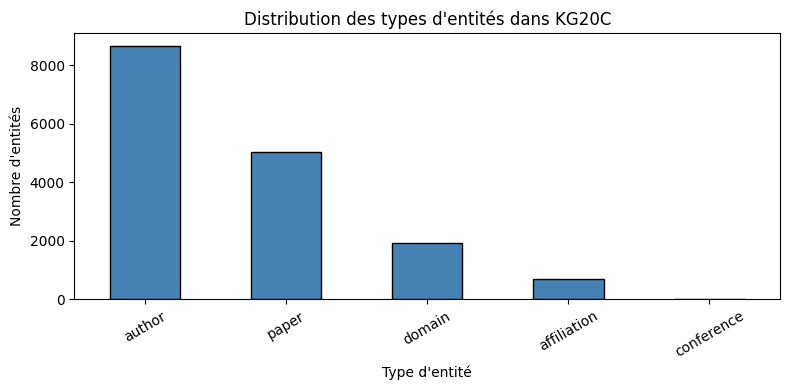

In [21]:

# === Étape 1 — Distribution des types d'entités (classes cibles) ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("=== Distribution des types d'entités (classes à prédire) ===")
class_counts = info['type'].value_counts()
print(class_counts.to_string())

plt.figure(figsize=(8, 4))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Distribution des types d'entités dans KG20C")
plt.xlabel("Type d'entité")
plt.ylabel("Nombre d'entités")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [26]:

# === Étape 2 — Alignement des indices PyKEEN ↔ fichier info ===
# PyKEEN réindexe les entités (0..N). On récupère cet index pour extraire
# le bon embedding pour chaque entité du fichier info.
entity_to_id = result.training.entity_to_id
info['idx'] = info['id'].map(entity_to_id)
info_clean = info.dropna(subset=['idx']).sort_values('idx')

X = embeddings[info_clean['idx'].astype(int).values]
y = info_clean['type']

print(f"Entités dans info                : {len(info)}")
print(f"Entités alignées avec PyKEEN     : {len(info_clean)}")
print(f"Entités sans embedding (ignorées): {len(info) - len(info_clean)}")
print(f"\nShape de X (features)           : {X.shape}")
print(f"Distribution finale des classes  :")
print(y.value_counts().to_string())

# Alerte déséquilibre
ratio = y.value_counts().iloc[0] / y.value_counts().iloc[-1]
print(f"\nRatio max/min : {ratio:.0f}x → utilisation de class_weight='balanced'")


Entités dans info                : 16362
Entités alignées avec PyKEEN     : 16362
Entités sans embedding (ignorées): 0

Shape de X (features)           : (16362, 200)
Distribution finale des classes  :
type
author         8680
paper          5047
domain         1923
affiliation     692
conference       20

Ratio max/min : 434x → utilisation de class_weight='balanced'


In [27]:

# === Étape 3 — Split train / test stratifié ===
# stratify=y garantit que chaque classe est représentée
# dans la même proportion dans le train et le test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Taille du train : {len(X_train)} entités")
print(f"Taille du test  : {len(X_test)} entités")
print(f"\nDistribution dans le test (doit refléter la distribution globale) :")
print(y_test.value_counts().to_string())


Taille du train : 13089 entités
Taille du test  : 3273 entités

Distribution dans le test (doit refléter la distribution globale) :
type
author         1736
paper          1010
domain          385
affiliation     138
conference        4


In [28]:

# === Étape 4 — Entraînement du Random Forest ===
# class_weight='balanced' : pondère chaque classe inversement à sa fréquence
#   → un exemple de 'conference' (20 entités) a autant de poids que 867 exemples de 'author'
#   → sans cela, le modèle ignorerait les classes rares
clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
clf.fit(X_train, y_train)

print("Classifieur entraîné.")
print(f"  Features en entrée : {X_train.shape[1]} dimensions (100 Re + 100 Im)")
print(f"  Arbres             : {clf.n_estimators}")
print(f"  Classes            : {list(clf.classes_)}")


Classifieur entraîné.
  Features en entrée : 200 dimensions (100 Re + 100 Im)
  Arbres             : 100
  Classes            : ['affiliation', 'author', 'conference', 'domain', 'paper']


In [29]:

# === Étape 5 — Évaluation : rapport de classification par classe ===
from sklearn.metrics import accuracy_score, f1_score

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro',    zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy globale   : {acc:.2%}  ← trompeuse sur données déséquilibrées")
print(f"Macro F1-score     : {macro_f1:.2%}  ← indicateur honnête (moyenne non pondérée par classe)")
print(f"Weighted F1-score  : {weighted_f1:.2%}  ← pondéré par le support\n")

print("=== Rapport détaillé par classe ===")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy globale   : 80.72%  ← trompeuse sur données déséquilibrées
Macro F1-score     : 39.57%  ← indicateur honnête (moyenne non pondérée par classe)
Weighted F1-score  : 75.76%  ← pondéré par le support

=== Rapport détaillé par classe ===
              precision    recall  f1-score   support

 affiliation       0.00      0.00      0.00       138
      author       0.73      1.00      0.85      1736
  conference       0.00      0.00      0.00         4
      domain       1.00      0.12      0.21       385
       paper       0.99      0.85      0.92      1010

    accuracy                           0.81      3273
   macro avg       0.55      0.39      0.40      3273
weighted avg       0.81      0.81      0.76      3273




### Visualisation de l'espace latent RotatE — t-SNE

La matrice de classification montre *que* les classes minoritaires sont invisibles, mais pas *pourquoi*. La réponse est dans la **géométrie de l'espace d'embedding** lui-même.

**t-SNE** (van der Maaten & Hinton, 2008) est l'outil de référence dans les cours d'embeddings (*graphEmbeddingsPartIII*) pour projeter un espace de haute dimension ($\mathbb{C}^{100}$, soit 200 réels) en 2D en **préservant la structure locale** : deux entités proches dans l'espace RotatE le restent dans la projection 2D.

> Si `affiliation` et `conference` sont invisibles pour le random forest, c'est parce que leurs embeddings sont **géométriquement contenus dans les clusters `author`/`paper`** : le classifieur n'a aucune frontière naturelle à exploiter.

Cette visualisation est le **diagnostic** le plus convaincant pour justifier les pistes d'amélioration (type-constrained RotatE, R-GCN).


Sous-échantillon : 2020 entités
{'affiliation': np.int64(500), 'author': np.int64(500), 'conference': np.int64(20), 'domain': np.int64(500), 'paper': np.int64(500)}

Calcul t-SNE en cours (perplexity=30, max_iter=1000)...
t-SNE terminé.


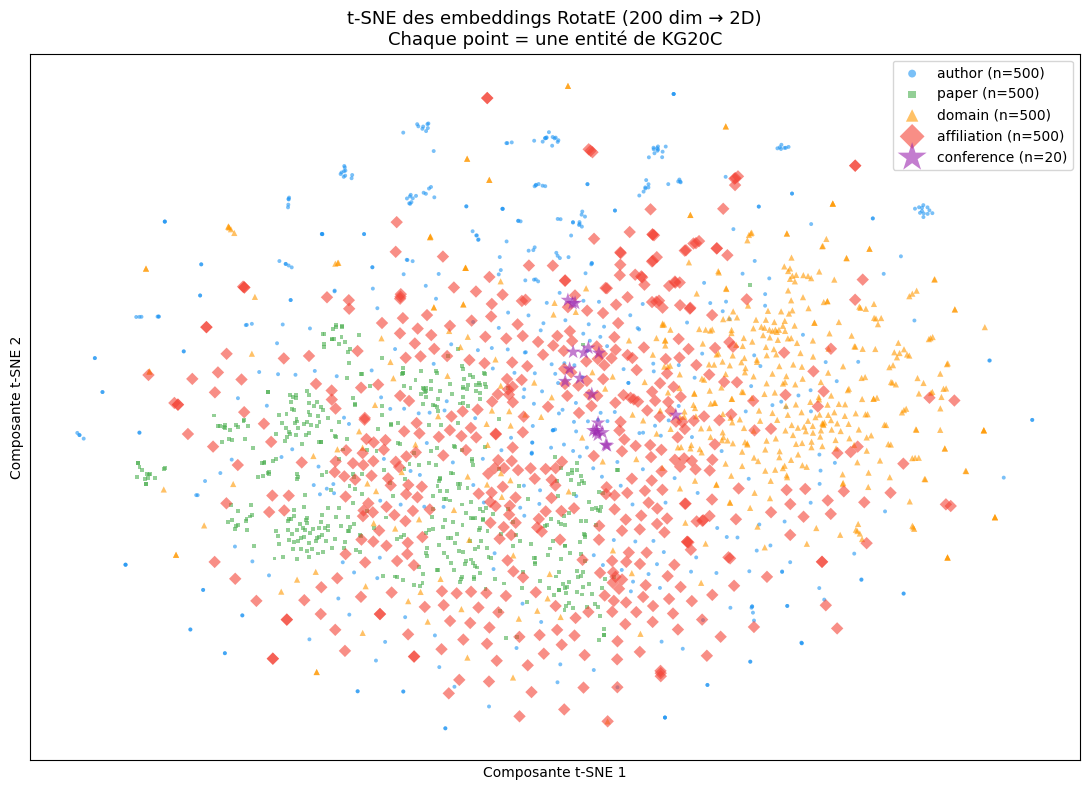

In [31]:

# === t-SNE de l'espace RotatE ===
# Diagnostic géométrique : pourquoi certaines classes sont-elles invisibles ?
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Sous-échantillonnage stratifié pour la vitesse (t-SNE est O(n²))
np.random.seed(42)
idx_sample = []
for cls in info_clean['type'].unique():
    cls_idx = info_clean[info_clean['type'] == cls].index
    n = min(500, len(cls_idx))
    idx_sample.extend(np.random.choice(cls_idx, n, replace=False))

sample = info_clean.loc[idx_sample]
X_sample = embeddings[sample['idx'].astype(int).values]
y_sample = sample['type'].values

print(f"Sous-échantillon : {len(X_sample)} entités")
print(dict(zip(*np.unique(y_sample, return_counts=True))))
print("\nCalcul t-SNE en cours (perplexity=30, max_iter=1000)...")

# scikit-learn >= 1.2 : n_iter renommé en max_iter
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_2d = tsne.fit_transform(X_sample)

print("t-SNE terminé.")

# --- Visualisation ---
colors = {
    'author':      '#2196F3',
    'paper':       '#4CAF50',
    'domain':      '#FF9800',
    'affiliation': '#F44336',
    'conference':  '#9C27B0',
}
markers = {
    'author': 'o', 'paper': 's', 'domain': '^', 'affiliation': 'D', 'conference': '*'
}
sizes = {
    'author': 8, 'paper': 8, 'domain': 20, 'affiliation': 40, 'conference': 120
}

fig, ax = plt.subplots(figsize=(11, 8))
for cls in ['author', 'paper', 'domain', 'affiliation', 'conference']:
    mask = y_sample == cls
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=colors[cls], marker=markers[cls], s=sizes[cls],
        alpha=0.6, label=f'{cls} (n={mask.sum()})', edgecolors='none'
    )

ax.set_title("t-SNE des embeddings RotatE (200 dim → 2D)\nChaque point = une entité de KG20C", fontsize=13)
ax.set_xlabel("Composante t-SNE 1")
ax.set_ylabel("Composante t-SNE 2")
ax.legend(loc='upper right', markerscale=2, fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


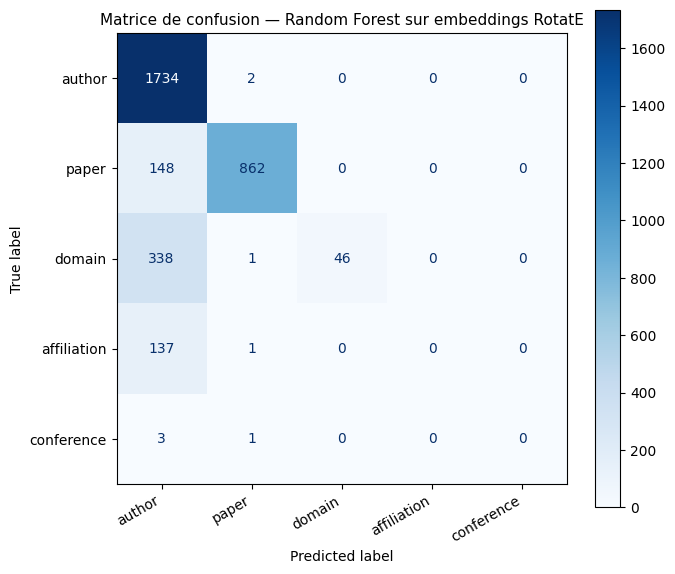

In [33]:

# === Matrice de confusion — où se perdent les classes minoritaires ? ===
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels_order = ['author', 'paper', 'domain', 'affiliation', 'conference']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title("Matrice de confusion — Random Forest sur embeddings RotatE", fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()



#### Lecture de la matrice de confusion

- Ligne = vraie classe, colonne = classe prédite.
- Les **`affiliation`** sont prédites `author` dans 137/138 cas : leurs embeddings tombent dans le cluster auteur.
- Les **`domain`** sont prédits `author` dans 338/385 cas (88 %) : les domaines et les auteurs ont un profil relationnel similaire, tous deux sont des entités qui reçoivent des connexions.
- Les **`conference`** sont toutes mal classées (3 vers `author`, 1 vers `paper`) : avec seulement 20 entités dans le dataset, le signal est insuffisant pour créer une région distincte dans l'espace RotatE.


### Interprétation de la classification downstream

#### Ce que le t-SNE révèle

La projection t-SNE ($\mathbb{C}^{100}$ → 2D) est le diagnostic le plus direct :
- **`author`** (bleu) et **`paper`** (vert) forment deux **nuages distincts** avec une certaine séparation géométrique → le classifieur peut tracer une frontière
- **`domain`** (orange) est **dispersé** dans l'espace, sans région propre → son profil relationnel (`paper_in_domain` : entité qui "reçoit" des papiers) ressemble à celui de `author`
- **`affiliation`** (rouge) est **totalement diffus**, éparpillé sur tout le graphe → aucune région exploitable
- **`conference`** (violet) est concentrée au **centre de la distribution**, exactement là où les clusters se chevauchent le plus

#### Ce que la matrice de confusion confirme

Toutes les classes minoritaires sont **absorbées dans `author`** :

| Vraie classe | → Prédit `author` | → Prédit `paper` | Correct |
|---|---|---|---|
| `author` (1 736) | **1 734** | 2 | 99.9 % |
| `paper` (1 010) | 148 | **862** | 85.3 % |
| `domain` (385) | **338** | 1 | 12 % (46/385) |
| `affiliation` (138) | **137** | 1 | 0 % |
| `conference` (4) | 3 | 1 | 0 % |

La matrice montre que le problème n'est pas algorithmique (le random forest est correct) mais **géométrique** : dans l'espace RotatE, `affiliation` et `domain` tombent dans la région `author`. C'est logique, `author`, `affiliation` et `domain` sont tous des entités qui **reçoivent** des liens (via `author_write_paper`, `author_in_affiliation`, `paper_in_domain`) et n'en **émettent** pas beaucoup. Leur position rotationnelle dans $\mathbb{C}^{100}$ est donc similaire.

#### Accuracy 81 % vs Macro F1 40 % : un écart révélateur

```
Accuracy globale  : 81 %   ← tirée par author (53 %) + paper (31 %)
Macro F1-score    : 40 %   ← pénalisé fortement par affiliation (0) et conference (0)
Weighted F1-score : 76 %   ← pondéré par le support
```

#### Pistes d'amélioration issues des cours

1. **Type-constrained RotatE** : encoder le type d'entité comme contrainte durant l'entraînement → force les affiliations à occuper une région distincte dans $\mathbb{C}^{100}$
2. **R-GCN** (*graphEmbeddingsPartIII*) : apprend une transformation $W_r$ **différente par relation** → `author_in_affiliation` et `author_write_paper` produiraient des représentations divergentes pour `author` vs `affiliation`
3. **SMOTE** : sur-échantillonnage des classes rares dans l'espace d'embedding avant classification
4. **Augmentation des epochs** (200-300) : avec plus de signal, RotatE pourrait commencer à séparer les entités par type implicitement



## Bilan du projet : Axe 2 : KG20C

---

### Ce que nous avons exploré

| Étape | Implémentation |
|---|---|
| Justification KGE vs GNN | Analyse du multi-relationnel, limite des agrégations indifférenciées |
| Limites de TransE | Démonstration mathématique de l'écrasement 1-N et de l'asymétrie |
| DistMult / ComplEx / RotatE | Comparatif des modèles complexes, focus sur la rotation dans $\mathbb{C}$ |
| Entraînement RotatE (PyKEEN) | `embedding_dim=100` (200 réels), `num_epochs=50`, CPU/GPU auto |
| Évaluation globale | MRR=0.113, Hits@10=20.0%, AMRI=0.790 sur le test set |
| Évaluation par relation | Asymétrie tail vs head confirmée (N-1 vs 1-N) |
| Downstream : Node Classification | Random Forest sur embeddings figés, `class_weight='balanced'`, macro F1 |
| **Visualisation t-SNE** | Projection 2D de $\mathbb{C}^{100}$, diagnostic géométrique de l'overlap entre classes |
| **Matrice de confusion** | Identification des confusions : `affiliation`/`domain` absorbés dans `author` |

---

### Justification des choix théoriques

#### Pourquoi un GNN classique ne suffit pas sur KG20C

Un GNN classique (GCN, GraphSAGE) agrège les messages de tous les voisins de façon **indifférenciée** :

$$h_v^{(k)} = \sigma\left(W \cdot \text{AGGREGATE}\left(\{h_u^{(k-1)} : u \in \mathcal{N}(v)\}\right)\right)$$

Cette formule ignore complètement le **type de la relation**. Or KG20C contient 5 types sémantiquement distincts :

| Relation | Nature |
|---|---|
| `author_write_paper` | 1-N |
| `paper_cite_paper` | N-N |
| `paper_in_domain` | N-1 |
| `author_in_affiliation` | N-1 |
| `paper_in_conference` | N-1 |

Un GNN traite une arête `author_write_paper` exactement comme une arête `paper_cite_paper` : il est aveugle à la sémantique relationnelle. Les méthodes KGE encodent **explicitement le type de relation** dans la fonction de scoring.

#### Pourquoi TransE échoue

TransE suppose $\mathbf{h} + \mathbf{r} \approx \mathbf{t}$. Sur une relation 1-N (ex. `author_write_paper`), un auteur $A$ ayant écrit $P_1$, $P_2$, $P_3$ impose $\mathbf{P}_1 \approx \mathbf{P}_2 \approx \mathbf{P}_3$ : **TransE écrase les embeddings** de toutes les entités partageant le même head et la même relation. Sur les relations asymétriques (citation non réciproque), TransE est incapable de distinguer $(h, r, t)$ de $(t, r, h)$.

| Propriété relationnelle | TransE | ComplEx | RotatE |
|---|---|---|---|
| Symétrie | ✓ | ✓ | ✓ ($\theta_r = 0$) |
| Antisymétrie | ✗ | ✓ | ✓ ($\theta_r \neq 0$) |
| Inversion | ✗ | ✓ | ✓ ($\theta_{r^{-1}} = -\theta_r$) |
| Relations 1-N | ✗ | ✓ | ✓ |
| Composition | ✗ | ✗ | ✓ |

#### Pourquoi RotatE dans $\mathbb{C}$

RotatE modélise chaque relation comme une **rotation** dans $\mathbb{C}^d$ :

$$\mathbf{h} \circ \mathbf{r} \approx \mathbf{t}, \quad r_i = e^{i\theta_{r,i}}, \quad |r_i| = 1$$

La rotation résout l'écrasement 1-N : deux rotations différentes de $\mathbf{h}$ peuvent pointer vers des entités distinctes $\mathbf{t}_1 \neq \mathbf{t}_2$. ComplEx (produit scalaire hermitien $\text{Re}(\langle \mathbf{h}, \mathbf{r}, \bar{\mathbf{t}} \rangle)$) couvre l'asymétrie mais pas la composition — RotatE est donc le choix le plus expressif des trois pour KG20C.

---

### Pistes non explorées

#### Type-constrained negative sampling (cours *graphEmbeddingsPartIII*)
**Pourquoi intéressant :** Lors de l'évaluation (corruption du tail), PyKEEN remplace le tail par *toutes* les entités, y compris des entités de type incompatible (ex: remplacer une `conference` par un `author`). Or un modèle qui ignore le type peut très bien classer un `author` devant une `conference` juste parce qu'`author` est plus fréquent.  
Le **type-constrained filtering** n'évalue que parmi les entités du type attendu → scores plus réalistes et plus élevés.  
**Pourquoi non fait :** PyKEEN ne supporte le type-filtering qu'avec un schéma ontologique explicite non fourni dans KG20C.
